In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [6]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


# Intro

- Artificial Neural Networks (ANNs) are machine learning models inspired by the structure and functioning of biological neurons in the human brain.

- The idea behind ANNs comes from observing nature, where many technological inventions were inspired by biological systems (e.g., birds inspiring airplanes, burdock plants inspiring Velcro).

- Although ANNs are inspired by biological neural networks, they have evolved to become quite different from real brain neurons.

- Some researchers suggest abandoning the biological analogy (e.g., using the term **units** instead of **neurons**) to avoid limiting innovation to biologically realistic systems.

- ANNs form the **core foundation of deep learning**.

- Key characteristics of Artificial Neural Networks:
  - Versatile
  - Powerful
  - Scalable
  - Capable of solving highly complex machine learning tasks.

- Examples of real-world applications of ANNs:
  - Image classification at massive scale (e.g., Google Images).
  - Speech recognition systems (e.g., Apple Siri).
  - Recommendation systems (e.g., YouTube video recommendations).
  - Game-playing AI systems (e.g., AlphaGo defeating the world champion in Go).

- Neural networks are capable of processing extremely large datasets and learning complex patterns from them.

- The chapter structure overview:
  - **Part 1:** Introduction to Artificial Neural Networks.
    - Historical development of early ANN architectures.
    - Progression toward **Multilayer Perceptrons (MLPs)**, which are widely used neural network architectures.

  - **Part 2:** Implementation of neural networks using **TensorFlow's Keras API**.

- **Keras API**:
  - A high-level API within TensorFlow designed for building and training neural networks.
  - Simplifies the process of creating, training, evaluating, and deploying neural networks.

- Advantages of Keras:
  - Simple and user-friendly design.
  - Highly expressive and flexible.
  - Suitable for building a wide range of neural network architectures.

- For advanced customization:
  - Developers can create **custom Keras components using the lower-level API**.
  - Or directly use **TensorFlow's lower-level functionalities** for maximum flexibility.

- Learning neural networks often begins with understanding their **historical development**, which explains how modern architectures evolved.

# From Biological to Artificial Neurons

- Artificial Neural Networks (ANNs) were first introduced in **1943** by:
  - **Warren McCulloch** (neurophysiologist)
  - **Walter Pitts** (mathematician)

- Their landmark paper:
  - *"A Logical Calculus of Ideas Immanent in Nervous Activity"*

- In this work, they proposed:
  - A **simplified computational model of biological neurons**.
  - A way neurons could work together to perform **complex computations using propositional logic**.

- This model became the **first artificial neural network architecture**.

- After this initial work, many new ANN architectures were developed over time.

- Early success of neural networks created optimism that **truly intelligent machines** would soon be built.

- During the **1960s**, progress slowed and expectations were not met, leading to:
  - Reduced research funding.
  - A period often called the **AI winter**.

- In the **early 1980s**:
  - New neural network architectures were proposed.
  - Improved training methods were developed.
  - This led to a revival of interest in **connectionism**.

- **Connectionism**:
  - A field of study focused on understanding intelligence through neural networks.

- Despite this revival, progress remained slow.

- In the **1990s**, other machine learning methods became popular, such as:
  - **Support Vector Machines (SVMs)**.

- These methods were preferred because they:
  - Produced strong results.
  - Had stronger theoretical foundations.

- As a result, neural network research again declined temporarily.

- Recently, there has been a **new surge of interest in ANNs (Deep Learning era)**.

- Key reasons why this wave of neural network research is different:

- **1. Availability of massive datasets**
  - Modern applications generate huge amounts of data.
  - Neural networks perform especially well on **large and complex datasets**.

- **2. Increased computing power**
  - Major improvements in hardware make training large networks feasible.

- **Moore's Law**:
  
  \( \text{Number of components in integrated circuits} \approx 2 \times \text{every 2 years} \)

  - This has led to exponential growth in computing power.

- **Graphics Processing Units (GPUs)**:
  - Originally developed for gaming.
  - Highly efficient for **parallel computation**.
  - Ideal for training neural networks.

- **Cloud computing platforms**
  - Provide scalable computing resources.
  - Allow researchers and companies to train large models without owning expensive hardware.

- **3. Improved training algorithms**
  - Modern algorithms are only slightly different from earlier ones.
  - However, small improvements significantly improved performance and stability.

- **4. Theoretical concerns proved less problematic**
  - Earlier belief: training algorithms would get stuck in **local optima**.

- **Local optimum**
  - A solution that is optimal within a nearby region but not globally optimal.

- **Global optimum**
  - The absolute best solution among all possible solutions.

- In practice:
  - Local optima often perform **almost as well as global optima**, especially in large neural networks.

- **5. Positive feedback cycle (virtuous circle)**

  - Successful ANN-based products attract attention.
  - Attention brings **more funding and research**.
  - More research leads to **better models and technologies**.
  - Better models create **more successful products**, continuing the cycle.

## Biological Neurons

In [7]:
# normla biology that you already know abouut nuerons nothing more but less

## Logical Computations with Neurons

- **McCulloch–Pitts Neuron (Artificial Neuron Model)**:
  - A simplified mathematical model of a biological neuron.
  - Introduced by **Warren McCulloch and Walter Pitts**.

- Basic characteristics of the McCulloch–Pitts neuron:
  - Has **one or more inputs**.
  - Inputs are **binary values**: $\(0\)$ (off) or $\(1\)$ (on).
  - Produces a **binary output**: $\(0\$) (inactive) or $\(1\)$ (active).

- **Activation mechanism**:
  - The neuron activates when the **number of active inputs exceeds a certain threshold**.

- General activation rule:

  $$\( y =
  \begin{cases}
  1, & \text{if } \sum x_i \geq \theta \\
  0, & \text{otherwise}
  \end{cases} \)$$

  where  
  $\(x_i\)$ = input signals  
  $\(\theta\)$ = activation threshold

- McCulloch and Pitts demonstrated that:
  - Networks of these simple artificial neurons can compute **any logical proposition**.

- This means that neural networks can represent **logical operations** and combine them to solve complex problems.

- Example assumption in the networks described:
  - A neuron activates if **at least two input connections are active**.

- **Identity Function Network**:
  - If neuron **A is active**, neuron **C becomes active**.
  - If neuron **A is inactive**, neuron **C remains inactive**.
  - Output equals input.

  $\( C = A \)$

- **Logical AND Network**:
  - Neuron **C activates only when both inputs are active**.

  $\( C = A \land B \)$

  - If only one input is active, neuron **C does not activate**.

- **Logical OR Network**:
  - Neuron **C activates if at least one input is active**.

  $\( C = A \lor B \)$

- **Logical NOT with Inhibitory Input**:
  - Some input connections can **inhibit neuron activation**.

- Inhibitory connection behavior:
  - If the inhibitory neuron is active, it **prevents activation of the target neuron**.

- Complex logical proposition example:
  - Neuron **C activates only if**:
    - $\(A = 1\)$
    - $\(B = 0\)$

  $\( C = A \land \neg B \)$

- If neuron **A is always active**, the network behaves like a **NOT gate**:

  $\( C = \neg B \)$

- Key insight:
  - By combining multiple artificial neurons, networks can compute **complex logical expressions**.

- This idea laid the **foundational concept for modern neural networks**.

## The Perceptron

- **Perceptron**
  - One of the earliest Artificial Neural Network architectures.
  - Invented in **1957 by Frank Rosenblatt**.

- The perceptron is based on a neuron model called a:
  - **Threshold Logic Unit (TLU)**
  - Also called **Linear Threshold Unit (LTU)**.

- Unlike the McCulloch–Pitts neuron:
  - Inputs are **numerical values**, not just binary \(0/1\).
  - Each input has an associated **weight**.

- Components of a TLU:
  - Inputs: $\(x_1, x_2, \dots, x_n\)$
  - Weights: $\(w_1, w_2, \dots, w_n\)$
  - Bias: $\(b\)$

- The neuron first computes a **linear combination of inputs**.

  $$\( z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b \)$$

- Vectorized form of the linear function:

  $$\( z = w^T x + b \)$$

- After computing \(z\), the neuron applies a **step activation function**.

  $$\( h_w(x) = \text{step}(z) \)$$

- Therefore the perceptron process is:
  - Compute weighted sum.
  - Apply step function.
  - Produce binary output.

- This is similar to **logistic regression**, except:
  - Logistic regression uses the **sigmoid (logistic) function**.
  - Perceptron uses a **step function**.

- Model parameters of the perceptron:
  - **Weights** $\(w\)$
  - **Bias** $\(b\)$

- **Common step functions used in perceptrons**

- **Heaviside Step Function**

  $$\( \text{heaviside}(z) =
  \begin{cases}
  0, & z < 0 \\
  1, & z \ge 0
  \end{cases} \)$$

- **Sign Function**

  $$\( \text{sgn}(z) =
  \begin{cases}
  -1, & z < 0 \\
  0, & z = 0 \\
  +1, & z > 0
  \end{cases} \)$$

- **Single TLU for Binary Classification**
  - Computes a linear function of inputs.
  - Compares the result to a threshold.
  - Outputs:
    - **Positive class** if threshold exceeded.
    - **Negative class** otherwise.

- Example application:
  - Classifying **iris flowers** based on:
    - petal length
    - petal width

- Training a TLU involves finding optimal values for:
  - $\(w_1, w_2, \dots, w_n\)$
  - $\(b\)$

- **Perceptron Architecture**

- A perceptron consists of:
  - One or more **TLUs arranged in a single layer**.

- In this structure:
  - Each neuron is connected to **all input features**.

- This type of layer is called:
  - **Fully Connected Layer**
  - **Dense Layer**

- Structure of a perceptron network:

  - **Input Layer**
    - Contains input features.
    - Does not perform computation.

  - **Output Layer**
    - Contains TLUs.
    - Produces final predictions.

- Example:
  - A perceptron with **2 inputs and 3 output neurons**
  - Each output neuron receives both input features.

---

>In mathematics, the sum of a matrix and a vector is undefined. However, in data science,
we allow “broadcasting”: adding a vector to a matrix means adding it to every row in the
matrix. So, XW + b first multiplies X by W—which results in a matrix with one row per
instance and one column per output—then adds the vector b to every row of that matrix,
which adds each bias term to the corresponding output, for every instance. Moreover, ϕ is
then applied itemwise to each item in the resulting matrix.

---

- A perceptron with multiple output neurons can perform **multiple binary classifications at the same time**.

- When a model predicts **several binary labels simultaneously**, it is called a **multilabel classifier**.

- The perceptron can also be adapted for **multiclass classification**, where an instance is assigned to **one class among multiple classes**.

- Neural networks rely heavily on **linear algebra** to efficiently compute outputs.

- Instead of computing neuron outputs one by one, we can compute **all neuron outputs for many instances simultaneously using matrix operations**.

- Output computation of a fully connected layer:

  $$\( h_{W,b}(X) = \phi(XW + b) \)$$

- Meaning of each component in the equation:

- **Input Matrix \(X\)**
  - Represents the dataset of input features.
  - Shape:
    
   $$ \( X \in \mathbb{R}^{m \times n} \)$$

  - Where:
    - $\(m\)$ = number of instances (samples)
    - $\(n\)$ = number of features

  - Each **row** corresponds to one instance.
  - Each **column** corresponds to one feature.

- **Weight Matrix \(W\)**
  - Contains all connection weights between inputs and neurons.

  - Shape:
    
    $$\( W \in \mathbb{R}^{n \times k} \)$$

  - Where:
    - $\(n\)$ = number of input features
    - $\(k\)$ = number of neurons in the layer

  - Each column corresponds to the **weights of one neuron**.

- **Bias Vector $\(b\$)**
  - Contains bias values for each neuron.

  - Shape:
    
    $$\( b \in \mathbb{R}^{k} \)$$

  - Each neuron has its own bias term.

- **Linear Transformation**

  $$\( Z = XW + b \)$$

  - Produces the weighted sum of inputs for every neuron and every instance.

- **Activation Function $\( \phi \$)**
  - Applied element-wise to the result.

  $$\( h_{W,b}(X) = \phi(Z) \)$$

- The **activation function** determines whether a neuron activates or how strongly it activates.

- In a perceptron using TLUs:
  - The activation function is a **step function**.

- Later neural networks use different activation functions such as:
  - Sigmoid
  - ReLU
  - Tanh

- Matrix-based computation allows neural networks to:
  - Process **many samples simultaneously**
  - Use **vectorized operations**
  - Achieve **efficient computation on GPUs**.

---

- **Perceptron Training**
  - The perceptron training algorithm was proposed by **Frank Rosenblatt**.
  - It was inspired by **Hebb’s rule** from neuroscience.

- **Hebb’s Rule (Hebbian Learning)**
  - Proposed by **Donald Hebb in 1949** in the book *The Organization of Behavior*.
  - Idea: when one neuron repeatedly activates another neuron, the connection between them becomes stronger.

- Famous summary of Hebb’s idea:

  **“Cells that fire together, wire together.”**

- Meaning:
  - If two neurons activate together frequently, their **connection weight increases**.

- This biological learning principle inspired early **learning algorithms for neural networks**.

- **Perceptron learning rule**
  - A modified version of Hebb’s rule.
  - Unlike pure Hebbian learning, it also considers the **prediction error**.

- Key idea:
  - Reinforce weights that help reduce prediction errors.

- **Training process of a perceptron**

  - Training is performed **one training instance at a time**.
  - For each instance:
    - The perceptron makes a **prediction**.
    - The prediction is compared with the **true label**.
    - If the prediction is wrong, the weights are updated.

- **Weight update rule**

  $$\( w_{i,j}^{(\text{next step})} = w_{i,j} + \eta (y_j - \hat{y}_j)x_i \)$$

- Meaning of variables:

- $\( w_{i,j} \)$
  - Weight connecting the **$\(i^{th}\)$ input** to the **$\(j^{th}\)$ neuron**.

- $\( x_i \)$
  - Value of the **$\(i^{th}\)$ input feature** for the current training instance.

- $\( \hat{y}_j \)$
  - **Predicted output** of the $\(j^{th}\)$ neuron.

- $\( y_j \)$
  - **True target output** for the $\(j^{th}\)$ neuron.

- $\( \eta \)$ (eta)
  - **Learning rate**.
  - Controls how large the weight update step is.

- **Interpretation of the update rule**

  - If the prediction is **correct**:
    - $$\(y_j - \hat{y}_j = 0\)$$
    - No weight update occurs.

  - If the prediction is **incorrect**:
    - The weights are adjusted in a direction that helps produce the correct output.

- Inputs that contributed to the error receive **larger corrections** depending on:
  - Input value $\(x_i\)$
  - Learning rate $\( \eta \)$

- Key intuition:
  - Strengthen connections that help make correct predictions.
  - Weaken connections that contribute to incorrect predictions.

---

> Contrary to logistic regression classifiers, perceptrons do not output a class probability.
This is one reason to prefer logistic regression over perceptrons. Moreover, perceptrons do
not use any regularization by default, and training stops as soon as there are no more
prediction errors on the training set, so the model typically does not generalize as well as
logistic regression or a linear SVM classifier. However, perceptrons may train a bit faster

- **Perceptron Decision Boundary**
  - The decision boundary produced by a perceptron is **linear**.

- Because of the linear decision boundary:
  - Perceptrons can only learn **linearly separable patterns**.
  - They **cannot learn complex nonlinear patterns**.

- This limitation is similar to other linear models such as:
  - **Logistic Regression**
  - **Linear SVM**

- **Linear Separability**
  - A dataset is linearly separable if a **straight line (or hyperplane in higher dimensions)** can perfectly separate the classes.

- If the data is linearly separable:
  - The perceptron training algorithm **guarantees convergence**.

- **Perceptron Convergence Theorem**
  - If the training data is **linearly separable**, the perceptron learning algorithm will eventually find a **set of weights that correctly classifies the data**.

- **Scikit-Learn Implementation**
  - Scikit-Learn provides a built-in **Perceptron class** for training perceptron models.

- The perceptron algorithm is closely related to **Stochastic Gradient Descent (SGD)**.

- In fact, the Scikit-Learn `Perceptron` class is equivalent to using:

  `SGDClassifier`

  with the following hyperparameters:

  - `loss = "perceptron"`
  - `learning_rate = "constant"`
  - `eta0 = 1`  → learning rate
  - `penalty = None` → no regularization

- **Major Limitation of Perceptrons**

  - Highlighted in **1969** by:
    - **Marvin Minsky**
    - **Seymour Papert**

  - In their book:
    - *Perceptrons*

- They showed that perceptrons **cannot solve certain simple problems**, including:

  - **XOR (Exclusive OR) problem**

- **XOR Logic**

  $$\( XOR(A,B) =
  \begin{cases}
  1, & A \ne B \\
  0, & A = B
  \end{cases} \)$$

- Truth table of XOR:

  | A | B | XOR |
  |---|---|-----|
  | 0 | 0 | 0 |
  | 0 | 1 | 1 |
  | 1 | 0 | 1 |
  | 1 | 1 | 0 |

- The XOR dataset is **not linearly separable**, meaning:
  - No single straight line can separate the classes.

- Because perceptrons produce **linear decision boundaries**, they cannot solve the XOR problem.

- This discovery caused major disappointment in the AI community.

- As a result:
  - Many researchers abandoned neural network research.
  - Focus shifted to areas like:
    - Logical reasoning
    - Problem solving
    - Search algorithms.

- Another reason for declining interest:
  - Neural networks had **few practical applications at the time**.

- **Solution to Perceptron Limitations**

  - Stack multiple perceptron layers together.

- This architecture is called a:

  **Multilayer Perceptron (MLP)**

- **Multilayer Perceptron (MLP)**
  - A neural network with **multiple layers of neurons**.
  - Includes hidden layers between input and output.

- MLPs can learn **nonlinear decision boundaries**.

- Therefore, MLPs **can solve the XOR problem**.

- Example behavior of an XOR-solving MLP:

  Inputs → Output

  - $\( (0,0) \rightarrow 0 \)$
  - $\( (1,1) \rightarrow 0 \)$
  - $\( (0,1) \rightarrow 1 \)$
  - $\( (1,0) \rightarrow 1 \)$

- Key insight:
  - **Stacking multiple layers of neurons increases the representational power of neural networks**, enabling them to learn complex patterns.

In [8]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

In [9]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)  # Iris setosa

In [10]:
per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [11]:
X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers

In [12]:
y_pred

array([ True, False])

In [13]:
# extra code – shows how to build and train a Perceptron

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="perceptron", penalty=None,
                        learning_rate="constant", eta0=1, random_state=42)
sgd_clf.fit(X, y)
assert (sgd_clf.coef_ == per_clf.coef_).all()
assert (sgd_clf.intercept_ == per_clf.intercept_).all()

>When the Perceptron finds a decision boundary that properly separates the classes, it stops learning. This means that the decision boundary is often quite close to one class:

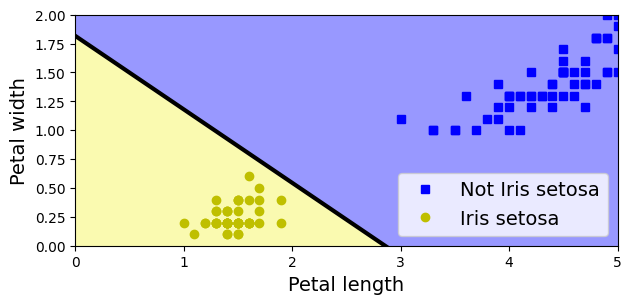

In [14]:
# extra code – plots the decision boundary of a Perceptron on the iris dataset

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-",
         linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
plt.show()

## The Multilayer Perceptron and Backpropagation

>The signal flows only in one direction (from the inputs to the outputs), so this architecture
is an example of a feedforward neural network (FNN).

- **Multilayer Perceptron (MLP) Structure**
  - An MLP consists of:
    - **Input layer**
    - **One or more hidden layers**
    - **Output layer**

- **Hidden Layers**
  - Composed of TLUs (neurons).
  - Perform intermediate computations between input and output.

- **Output Layer**
  - Produces the final predictions of the network.

- **Layer terminology**
  - Layers closer to input → **Lower layers**
  - Layers closer to output → **Upper layers**

- **Deep Neural Network (DNN)**
  - When an ANN has **many hidden layers**, it is called a DNN.

- **Deep Learning**
  - Field focused on training and studying **deep neural networks**.
  - More generally, refers to models with **multiple layers of computation**.

- Note:
  - In practice, the term **deep learning** is often used even for shallow networks.

- **Challenge in training MLPs (historically)**
  - Researchers struggled to train MLPs effectively for many years.

- Idea of using **Gradient Descent**
  - Proposed in the early 1960s.
  - Requires computing gradients of error with respect to parameters.

- Problem:
  - Hard to compute gradients efficiently for:
    - Many layers
    - Large number of parameters
  - Limited computational power at the time.

- **Breakthrough in 1970**
  - Introduced by **Seppo Linnainmaa**.

- He developed:
  - **Reverse-Mode Automatic Differentiation (Autodiff)**

- **Reverse-Mode Autodiff**
  - Efficient method to compute gradients of complex models.
  - Works using **two passes through the network**:

  - **Forward Pass**
    - Input data flows through the network.
    - Predictions are computed.

  - **Backward Pass**
    - Gradients of error are computed for all parameters.

- This method computes:
  - Gradient of error with respect to:
    - Each weight
    - Each bias

- These gradients indicate:
  - How each parameter should be adjusted to reduce error.

- **Gradient Descent Update**

  $$( \theta = \theta - \eta \nabla_\theta J(\theta))$$

  where:
  - $\( \theta \)$ = model parameters (weights and biases)
  - $\( \eta \)$ = learning rate
  - $\( \nabla_\theta J(\theta) \)$ = gradient of loss function

- **Backpropagation (Backprop)**
  - Combination of:
    - Reverse-mode autodiff
    - Gradient descent

- Backpropagation process:
  - Compute predictions (forward pass)
  - Compute error
  - Compute gradients (backward pass)
  - Update parameters using gradient descent

- By repeating this process:
  - The network’s error **gradually decreases**
  - Eventually reaches a **minimum (optimal or near-optimal solution)**

- Key insight:
  - Backpropagation made it possible to **efficiently train deep neural networks**, enabling modern deep learning.

>There are various autodiff techniques, with different pros and cons. Reverse-mode autodiff
is well suited when the function to differentiate has many variables (e.g., connection
weights and biases) and few outputs (e.g., one loss). If you want to learn more about
autodiff

---

- **Backpropagation is not limited to neural networks**
  - It can be applied to any **computational graph**.
  - Originally introduced by **Seppo Linnainmaa** in a general context (not specifically for neural networks).

- Backpropagation became widely used in neural networks after:
  - **1985 paper by:**
    - David Rumelhart
    - Geoffrey Hinton
    - Ronald Williams

- Their contribution:
  - Demonstrated that backpropagation allows neural networks to learn **useful internal representations**.
  - This led to rapid adoption of backpropagation in the ML community.

- Today:
  - Backpropagation is the **most widely used training algorithm** for neural networks.

- **Training Process of Backpropagation**

- **1. Mini-batch Gradient Descent**
  - Training is done using **mini-batches** (e.g., 32 samples at a time).
  - Instead of using the entire dataset at once.

- **2. Epoch**
  - One full pass through the entire training dataset is called an **epoch**.
  - Training typically involves multiple epochs.

- **3. Forward Pass**
  - Input data from a mini-batch is fed into the network.
  - Data flows layer by layer:
    - Input → Hidden layers → Output layer

  - At each layer:
    - Compute weighted sum
    - Apply activation function

  - Intermediate results are **stored** for use in backpropagation.

- **4. Loss Computation**
  - The network’s output is compared with the true labels.
  - A **loss function** calculates the error.

  Example:

  $$( \text{Loss} = J(y, \hat{y}) )$$

- **5. Backward Pass (Gradient Computation)**
  - Compute how much each parameter contributed to the error.

- Uses **Chain Rule (Calculus)**:
  
  $$( \frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x) )$$

- Steps:
  - Start from the output layer.
  - Compute gradients of loss w.r.t:
    - Output weights
    - Output biases

  - Propagate error backward through layers:
    - Compute gradients for hidden layers
    - Continue until input layer

- This process computes:

  $$( \frac{\partial J}{\partial w}, \quad \frac{\partial J}{\partial b} )$$

  for all weights and biases.

- **6. Gradient Descent Update**
  - Update all parameters using computed gradients:

  $$( w = w - \eta \frac{\partial J}{\partial w} )$$

  $$( b = b - \eta \frac{\partial J}{\partial b} )$$

- **Key Insight**
  - Backpropagation efficiently computes gradients for **all parameters in the network**.
  - It does this by **propagating error backward** through layers.

- **Overall Flow**
  - Forward pass → Compute predictions
  - Compute loss → Measure error
  - Backward pass → Compute gradients
  - Update parameters → Reduce error

- Repeating this process:
  - Gradually reduces loss
  - Improves model performance

- Backpropagation is the **core mechanism enabling deep learning**.

---

>It is important to initialize all the hidden layers’ connection weights randomly, or else
training will fail. For example, if you initialize all weights and biases to zero, then all
neurons in a given layer will be perfectly identical, and thus backpropagation will affect
them in exactly the same way, so they will remain identical. In other words, despite having
hundreds of neurons per layer, your model will act as if it had only one neuron per layer: it
won’t be too smart. If instead you randomly initialize the weights, you break the symmetry
and allow backpropagation to train a diverse team of neurons.

---

- **Backpropagation Summary**
  - Forward pass → compute predictions for a mini-batch.
  - Compute loss → measure prediction error.
  - Reverse pass → compute error contribution of each parameter.
  - Gradient descent → update weights and biases to reduce error.

- **Problem with Step Function**
  - Step function has **flat regions**.
  - Gradient is **zero everywhere except at threshold**.
  - Gradient Descent cannot work properly without gradients.

- **Solution: Replace Step Function with Sigmoid**

- **Sigmoid (Logistic) Function**

  $$( \sigma(z) = \frac{1}{1 + e^{-z}} )$$

- Properties:
  - Smooth and continuous.
  - Differentiable everywhere.
  - Output range: ( (0, 1) )

- Advantage:
  - Provides **non-zero gradients**, enabling learning with gradient descent.

- Backpropagation works with many activation functions, not just sigmoid.

- **Hyperbolic Tangent (tanh)**

  $$( \tanh(z) = 2\sigma(2z) - 1 )$$

- Properties:
  - S-shaped like sigmoid.
  - Output range: ( (-1, 1) )
  - Centered around zero.

- Advantage:
  - Zero-centered outputs help:
    - Faster convergence
    - Better gradient flow in early training

- **ReLU (Rectified Linear Unit)**

  $$( \text{ReLU}(z) = \max(0, z) )$$

- Properties:
  - Outputs:
    - $(0\) if \(z < 0)$
    - $(z\) if \(z \ge 0)$
  - Not differentiable at (z = 0)
  - Gradient is:
    - $(0\)$ for $\(z < 0)$
    - $(1\)$ for $\(z > 0)$

- Advantages:
  - Computationally efficient (very fast).
  - Works well in practice.
  - Helps reduce some gradient-related issues.
  - No upper bound → avoids saturation problems.

- ReLU has become the **default activation function** in many deep learning models.

- **Why Activation Functions Are Necessary**

- Without activation functions:
  - Neural networks perform only **linear transformations**.

- Example:

  $$( f(x) = 2x + 3 $$)

  $$( g(x) = 5x - 1 $$)

  $$( f(g(x)) = 2(5x - 1) + 3 = 10x + 1 $$)

- Insight:
  - Composition of linear functions is still **linear**.

- Therefore:
  - A deep network without activation functions behaves like a **single-layer linear model**.

- Limitation:
  - Cannot learn complex patterns.

- **Role of Activation Functions**
  - Introduce **nonlinearity** into the network.
  - Enable learning of **complex and nonlinear relationships**.

- **Expressive Power of Neural Networks**
  - A sufficiently large **deep neural network with nonlinear activations** can:
    - Approximate **any continuous function**.

- Key takeaway:
  - Activation functions are essential for making neural networks **powerful and expressive**.

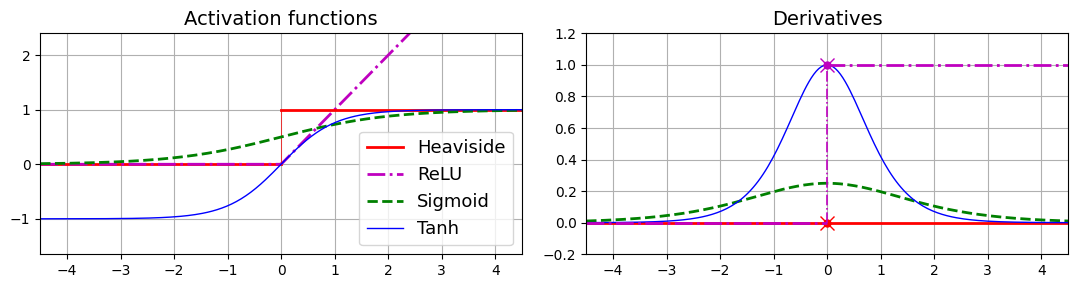

In [15]:
# extra code – this cell generates and saves Figure 10–8

from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

save_fig("activation_functions_plot")
plt.show()

## Regression MLPs

- MLPs can be used for **regression tasks**.

- **Single output neuron** → predicts one value (e.g., house price).

- **Multiple output neurons** → used for multivariate regression:
  - Example: predicting coordinates → 2 neurons
  - Bounding box (x, y, width, height) → 4 neurons

- **MLPRegressor (Scikit-Learn)** is used for regression with neural networks.

- Important preprocessing:
  - **Feature scaling (standardization)** is necessary for gradient descent to work properly.

- Common setup:
  - Hidden layers with multiple neurons (e.g., 3 layers × 50 neurons).
  - **ReLU activation** in hidden layers.
  - **Adam optimizer** (variant of gradient descent).
  - Loss function: **Mean Squared Error (MSE)**

  $$\( \text{MSE} = \frac{1}{n} \sum (y - \hat{y})^2 $$)

- Regularization:
  - **L2 regularization** controlled by hyperparameter $\( \alpha )$.

---

Warning: In recent versions of Scikit-Learn, you must use root_mean_squared_error() to compute the RMSE, instead of mean_squared_error(labels, predictions, squared=False). The following try/except block tries to import root_mean_squared_error, and if it fails it just defines it.

In [16]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

In [17]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor

In [18]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

In [19]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)

In [20]:
rmse

0.505332665796845

In [21]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('mlpregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[50, 50, ...]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural

---

- Model performance:
  - Validation **RMSE ≈ 0.505**, comparable to Random Forest.

- Output layer behavior:
  - No activation function → output can be **any real value**.

- To restrict output values:

- **Positive outputs only**:
  - Use **ReLU** or **Softplus**

  $$( \text{Softplus}(z) = \log(1 + e^z) )$$

  - Softplus:
    - ≈ 0 for negative \(z\)
    - ≈ (z\) for positive \(z\)

- **Bounded outputs**:
  - Use:
    - **Sigmoid** → range \( (0,1) \)
    - **tanh** → range \( (-1,1) \)

  - Requires scaling target values accordingly.

- Limitation:
  - `MLPRegressor` **does not support output layer activation functions**.

- Warning:
  - Scikit-Learn MLP is simple but **limited**.
  - More flexibility → use **Keras (TensorFlow)**.

- Loss functions for regression:

- **Mean Squared Error (MSE)** (default)

  $$( \text{MSE} = \frac{1}{n} \sum (y - \hat{y})^2 )$$

  - Sensitive to outliers.

- **Mean Absolute Error (MAE)**

  $$( \text{MAE} = \frac{1}{n} \sum |y - \hat{y}| )$$

  - More robust to outliers.

- **Huber Loss**
  - Combines MSE and MAE:
    - Quadratic for small errors.
    - Linear for large errors.

  - Benefits:
    - Less sensitive to outliers than MSE.
    - More stable and precise than MAE.

- Limitation:
  - `MLPRegressor` supports **only MSE**.

---

| Hyperparameter            | Typical Value                                                                 |
|--------------------------|-------------------------------------------------------------------------------|
|  hidden layers          | Depends on problem, typically 1 to 5                                         |
|  neurons per hidden layer | Depends on problem, typically 10 to 100                                      |
|  output neurons         | 1 per prediction dimension                                                   |
| Hidden activation        | ReLU                                                                         |
| Output activation        | None, or ReLU/softplus (for positive outputs), or sigmoid/tanh (for bounded outputs) |
| Loss function            | MSE, or Huber (if outliers present)                                          |

## Classification MLPs

- MLPs can be used for **classification tasks**.

- **Binary Classification**
  - Use **1 output neuron**.
  - Activation: **Sigmoid**

  $$( \sigma(z) = \frac{1}{1 + e^{-z}} )$$

  - Output:
    - Value in \( (0,1) \) → probability of positive class
    - Negative class probability = \( 1 - p \)

- **Multilabel Classification**
  - Use **1 output neuron per label**.
  - Activation: **Sigmoid (for each neuron)**

  - Example:
    - Spam detection + urgency detection → 2 neurons

  - Output probabilities:
    - Do **not sum to 1**
    - Model can predict multiple labels simultaneously

- **Multiclass Classification (exclusive classes)**
  - Use **1 output neuron per class**.
  - Activation: **Softmax**

  $$( \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}} )$$

  - Properties:
    - Outputs are in \( (0,1) \)
    - Sum of probabilities = 1

- **Loss Function for Classification**
  - Use **Cross-Entropy Loss**

  $$( J = -\sum y \log(\hat{y}) )$$

  - Suitable for probability predictions.

- **Scikit-Learn Implementation**
  - Use `MLPClassifier` (similar to `MLPRegressor`).
  - Uses:
    - Cross-entropy loss (instead of MSE)

- Notes:
  - Feature scaling is important.
  - Simple tasks (like Iris dataset):
    - 1 hidden layer
    - ~5–10 neurons is sufficient.

---

| Configuration            | Binary Classification | Multilabel Classification | Multiclass Classification |
|--------------------------|----------------------|---------------------------|---------------------------|
| hidden layers          | 1                    | 1                         | 1                         |
| output neurons         | 1                    | 1 per binary label        | 1 per class               |
| Output layer activation  | Sigmoid              | Sigmoid                   | Softmax                   |
| Loss function            | X-entropy            | X-entropy                 | X-entropy                 |

---

In [22]:
# extra code – this was left as an exercise for the reader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

In [23]:
data = load_iris()
X_train_full, X_test, y_train_full, y_test = train_test_split(iris.data, iris.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)

In [24]:
mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_valid, y_valid)
accuracy

1.0

# Exercises 1

> **The [TensorFlow playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.25787&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) is a handy neural network simulator built
by the TensorFlow team. In this exercise, you will train several binary
classifiers in just a few clicks, and tweak the model’s architecture and its
hyperparameters to gain some intuition on how neural networks work
and what their hyperparameters do. Take some time to explore the
following:**

- a. The patterns learned by a neural net. Try training the default neural network by clicking the Run button (top left). Notice how it quickly finds a good solution for the classification task. The neurons in the first hidden layer have learned simple patterns, while the neurons in the second hidden layer have learned to combine the simple patterns of the first hidden layer into more complex patterns. In general, the more layers there are, the more complex the patterns can be.
- b. Activation functions. Try replacing the tanh activation function
with a ReLU activation function, and train the network again.
Notice that it finds a solution even faster, but this time the
boundaries are linear. This is due to the shape of the ReLU
function.
- c. The risk of local minima. Modify the network architecture to have
just one hidden layer with three neurons. Train it multiple times (to
reset the network weights, click the Reset button next to the Play
button). Notice that the training time varies a lot, and sometimes it
even gets stuck in a local minimum.
- d. What happens when neural nets are too small. Remove one neuron
to keep just two. Notice that the neural network is now incapable of
finding a good solution, even if you try multiple times. The model
has too few parameters and systematically underfits the training set.
- e. What happens when neural nets are large enough. Set the number
of neurons to eight, and train the network several times. Notice that
it is now consistently fast and never gets stuck. This highlights an
important finding in neural network theory: large neural networks
rarely get stuck in local minima, and even when they do these local
optima are often almost as good as the global optimum. However,
they can still get stuck on long plateaus for a long time.
- f. The risk of vanishing gradients in deep networks. Select the spiral
dataset (the bottom-right dataset under “DATA”), and change the
network architecture to have four hidden layers with eight neurons
each. Notice that training takes much longer and often gets stuck on
plateaus for long periods of time. Also notice that the neurons in
the highest layers (on the right) tend to evolve faster than the
neurons in the lowest layers (on the left). This problem, called the
vanishing gradients problem, can be alleviated with better weight
initialization and other techniques, better optimizers (such as
AdaGrad or Adam), or batch normalization
- g. Go further. Take an hour or so to play around with other parameters
and get a feel for what they do, to build an intuitive understanding
about neural networks.

# Implementing MLPs with Keras

- **Keras**
  - High-level API of **TensorFlow** for building and training neural networks.

- Developed by **François Chollet** (2015).

- Key features:
  - Easy to use
  - Flexible
  - Clean and intuitive design

- Keras is now **TensorFlow-only** (since version 2.4).

- TensorFlow 2 officially uses **Keras as its main high-level API**.

- Installing TensorFlow automatically installs Keras.

- Keras cannot work without TensorFlow.

- Other popular deep learning libraries:
  - PyTorch (Facebook)
  - JAX (Google)

- Keras is commonly used to build models like:
  - MLPs for image classification

- Note:
  - Google Colab already has TensorFlow and Keras preinstalled.

---

## Building an Image Classifier Using the Sequential API

In [25]:
#  the images represent fashion items rather than handwritten digits,

### Using Keras to load the dataset

- Keras provides built-in datasets like **MNIST** and **Fashion MNIST**.

- **Fashion MNIST dataset**
  - 60,000 training images
  - 10,000 test images

- Data splitting:
  - Training set → 55,000 samples
  - Validation set → 5,000 samples
  - Test set → 10,000 samples

- Each image:
  - Shape: $(28 \times 28)$
  - Data type: `uint8`
  - Pixel range: $(0)$ to $(255)$

- Preprocessing:
  - Scale pixel values to (0-1):

  $$( X = \frac{X}{255.0} )$$

- Labels:
  - Represent **class indices (0–9)**

- Class names:
  - T-shirt/top, Trouser, Pullover, Dress, Coat
  - Sandal, Shirt, Sneaker, Bag, Ankle boot

- Example:
  - `y_train[0] → "Ankle boot"`

- Note:
  - TensorFlow is imported as `tf`
  - Keras API is accessed via `tf.keras`

---

In [7]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [27]:
X_train.shape

(55000, 28, 28)

In [28]:
X_train.dtype

dtype('uint8')

In [29]:
# Let's scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

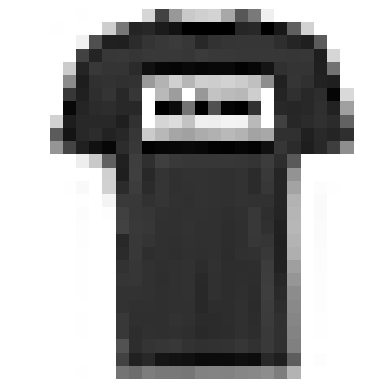

In [30]:
# extra code to  plot an image
# You can plot an image using Matplotlib's imshow() function, with a 'binary' color map:
plt.imshow(X_train[1], cmap="binary")
plt.axis('off')
plt.show()

In [31]:
y_train

array([9, 0, 0, ..., 9, 0, 2], shape=(55000,), dtype=uint8)

In [32]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [33]:
class_names[y_train[1]]

'T-shirt/top'

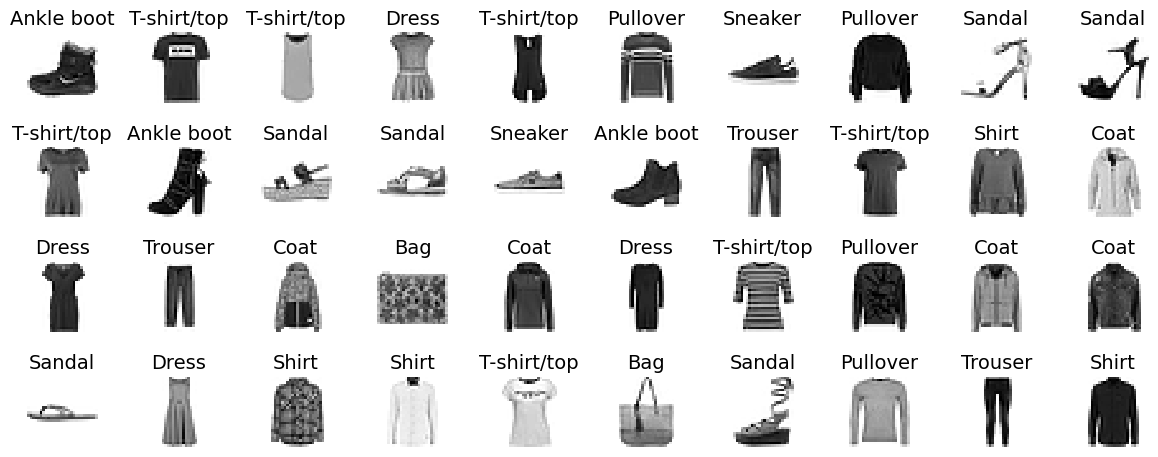

In [34]:
# extra code – this cell generates and saves Figure 10–10

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

save_fig("fashion_mnist_plot")
plt.show()

### Creating the model using the sequential API

- Set random seed:
  - Ensures **reproducibility** of results.

- **Sequential Model**
  - Simple stack of layers connected sequentially.

- **Input Layer**
  - Shape: ([28, 28])
  - Defines input size (image dimensions).

- **Flatten Layer**
  - Converts $(28 \times 28)$ image → (784)-dim vector:

  $$( X \rightarrow X.\text{reshape}(-1, 784) )$$

- **Hidden Layer 1**
  - 300 neurons
  - Activation: ReLU

- **Hidden Layer 2**
  - 100 neurons
  - Activation: ReLU

- **Dense Layer Computation**

  $$( Z = XW + b )$$

- **Output Layer**
  - 10 neurons (one per class)
  - Activation: Softmax

  $$( \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}} )$$

- Purpose:
  - Outputs **probability distribution** over classes.

---

In [35]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [36]:
# extra code – clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

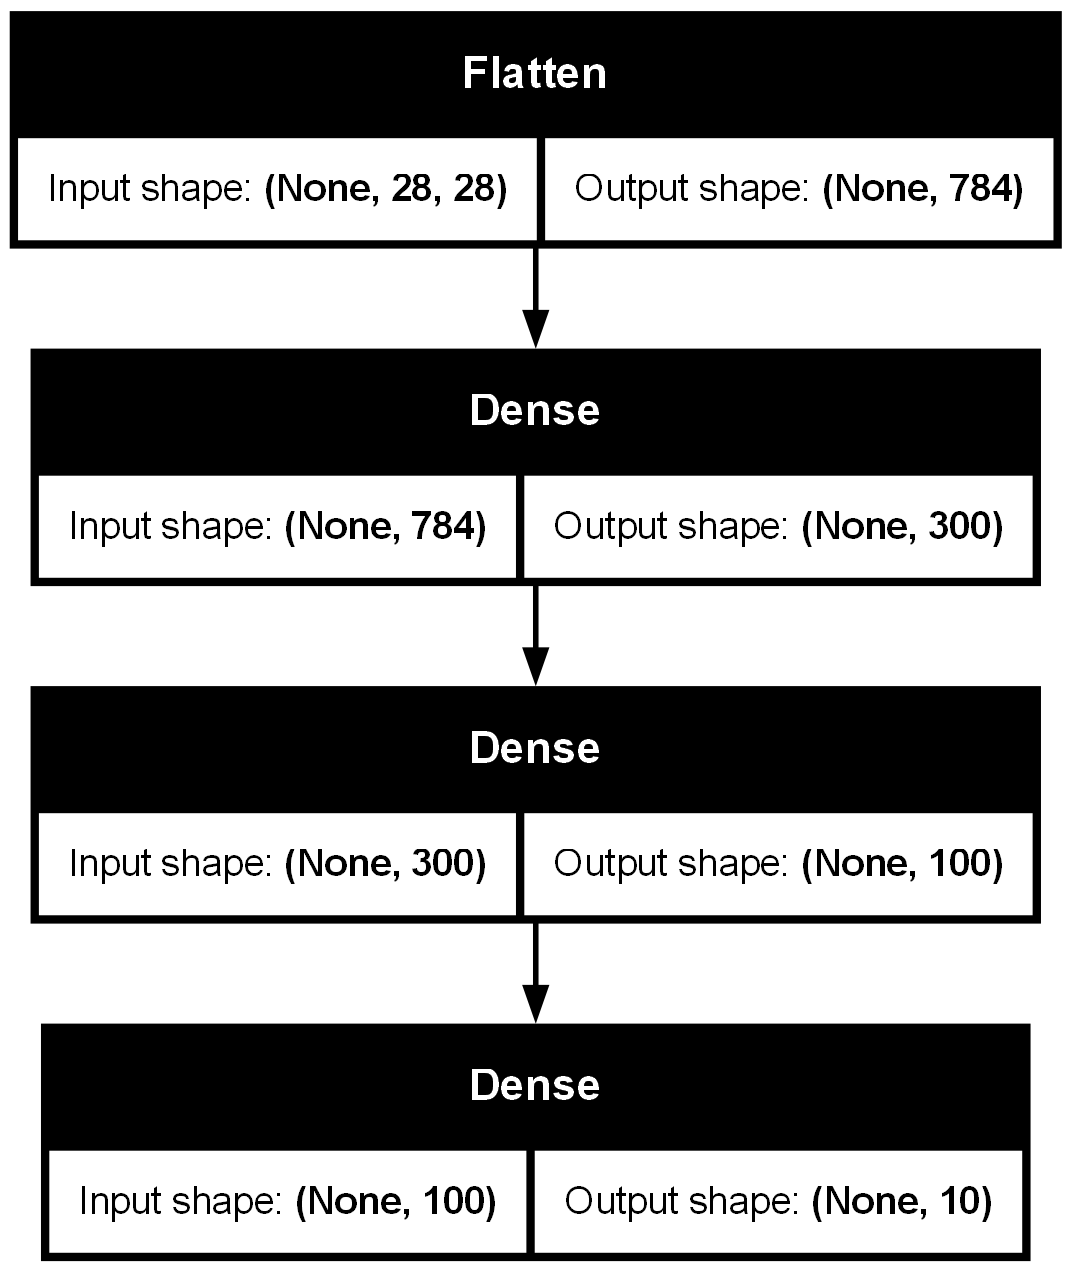

In [38]:
# extra code – another way to display the model's architecture
# requires the package pydot
tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [39]:
# !pip install pydot

In [40]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [41]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [42]:
model.get_layer('dense') is hidden1

True

In [43]:
weights, biases = hidden1.get_weights()
weights

array([[-0.06191043,  0.06675653,  0.00098883, ..., -0.03592802,
        -0.07426396,  0.01253664],
       [-0.03532792, -0.05279   ,  0.03194715, ...,  0.00076228,
        -0.04785703,  0.03278571],
       [-0.01808823, -0.06439797,  0.02551387, ...,  0.02263024,
        -0.06195045,  0.00119296],
       ...,
       [-0.03126304, -0.039758  , -0.02883439, ..., -0.05715122,
         0.02536554, -0.03927899],
       [-0.03476041, -0.02207157, -0.01834612, ..., -0.03386985,
        -0.00247234,  0.05399539],
       [ 0.03876787, -0.0127275 ,  0.05431333, ...,  0.02960391,
         0.03651407,  0.06357972]], shape=(784, 300), dtype=float32)

In [44]:
weights.shape

(784, 300)

In [45]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [46]:
biases.shape

(300,)

>The shape of the weight matrix depends on the number of inputs, which is why we
specified the input_shape when creating the model. If you do not specify the input shape,
it’s OK: Keras will simply wait until it knows the input shape before it actually builds the
model parameters. This will happen either when you feed it some data (e.g., during
training), or when you call its build() method. Until the model parameters are built, you
will not be able to do certain things, such as display the model summary or save the
model. So, if you know the input shape when creating the model, it is best to specify it.

- **Sequential Model Creation**
  - Layers can be passed as a **list** during model creation.
  - Input layer can be skipped by using `input_shape` in first layer.

- **model.summary()**
  - Shows:
    - Layer names
    - Output shapes
    - Number of parameters
  - `None` in shape → batch size can vary.

- **Parameter Calculation (Dense layer)**

  $$( \text{params} = (\text{inputs} \times \text{neurons}) + \text{biases} )$$

  - Example:
    
    $$( 784 \times 300 + 300 = 235{,}500 )$$

- Large number of parameters:
  - Increases **model flexibility**
  - Risk of **overfitting**

- **Layer Naming**
  - Auto-generated by Keras (e.g., `dense`, `dense_1`)
  - Ensures **global uniqueness**
  - Helps in merging models without conflicts

- **Keras Session**
  - Stores global state (e.g., layer names)
  - Reset using:

  `tf.keras.backend.clear_session()`

- **Accessing Layers**
  - List all layers:

    `model.layers`

  - Access specific layer:

    `model.get_layer("layer_name")`

- **Weights and Biases**
  - Access using:

    `get_weights()`

  - Returns:
    - Weight matrix (W)
    - Bias vector (b)

- **Weight Shapes**
  - Example:
    
    $$( W \in \mathbb{R}^{784 \times 300} )$$

    $$( b \in \mathbb{R}^{300} )$$

- **Initialization**
  - Weights → random (breaks symmetry)
  - Biases → zeros

- Custom initialization:
  - `kernel_initializer` → weights
  - `bias_initializer` → biases

- **Input Shape Importance**
  - Required to determine weight dimensions.
  - If not provided:
    - Model builds lazily during first data pass.
  - Without build:
    - Cannot view summary or save model.

- Best practice:
  - Always specify **input shape** when creating model.

---

### Compiling the model

- After building a model, use **compile()** to configure training.

- Example:

  `model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])`

- **Loss Function**
  - **sparse_categorical_crossentropy**:
    - Used when labels are **integers (class indices)**.
  - **categorical_crossentropy**:
    - Used when labels are **one-hot encoded**.
  - **binary_crossentropy**:
    - Used for **binary or multilabel classification**.

- **Label formats**
  - Sparse: ( y = 3 )
  - One-hot: $( y = [0,0,0,1,0,...] )$

- Convert labels:
  - To one-hot → `tf.keras.utils.to_categorical()`
  - Back to index → `np.argmax(axis=1)`

- **Optimizer**
  - `"sgd"` → Stochastic Gradient Descent
  - Performs:
    - Backpropagation + Gradient Descent

- Custom learning rate (important):

  `optimizer = tf.keras.optimizers.SGD(learning_rate=\eta)`

- Default learning rate:
  
  $( \eta = 0.01 $)

- **Metrics**
  - `"accuracy"`:
    - Measures prediction correctness during training and evaluation.

- Key idea:
  - compile() defines:
    - **how model learns (optimizer)**
    - **what it optimizes (loss)**
    - **how performance is measured (metrics)**

In [47]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [48]:
# This is equivalent to:
# extra code – this cell is equivalent to the previous cell
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [49]:
# extra code – shows how to convert class ids to one-hot vectors
tf.keras.utils.to_categorical([0, 5, 1, 0], num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [50]:
# Note: it's important to set num_classes when the number of classes is greater than the maximum class id

In [51]:
# extra code – shows how to convert one-hot vectors to class ids
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0])

### Training and evaluating the model

- **Training the model**

  `history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))`

- **Inputs to fit()**
  - $(X_{train})$ → input features
  - $(y_{train})$ → target labels
  - epochs → number of full passes over dataset
  - validation_data → evaluate performance on unseen data

---

- **Epoch Output**
  - loss → training error
  - accuracy → training performance
  - val_loss → validation error
  - val_accuracy → validation performance

---

- **Batch Processing**
  - Batch size = 32 (default)
  - Total batches per epoch:

  $$( \frac{55000}{32} \approx 1719 )$$

  - 1718 batches of size 32  
  - 1 batch of size 24  

---

- **Training Flow**
  - Each batch:
    - Forward pass → predictions
    - Loss computation
    - Backward pass → gradients
    - Weight update

---

- **Observations**
  - Training loss ↓ → model is learning ✅
  - Validation accuracy ≈ 88.94% → good performance ✅

---

- **Overfitting**
  - Training accuracy > Validation accuracy
  - Slight gap → **mild overfitting (acceptable)**

---

- **history object**
  - Stores:
    - loss, accuracy
    - val_loss, val_accuracy
  - Used for plotting learning curves

---

- **Validation Options**
  - Explicit:

    `validation_data=(X_valid, y_valid)`

  - Automatic split:

    `validation_split=0.1`

---

- **Common Errors**
  - Shape mismatch (wrong input dimensions)
  - Wrong loss function for label format
  - Missing Flatten layer for image data

---

- **Key Insight**
  - fit() performs:
    - forward pass → compute output
    - loss → measure error
    - backward pass → compute gradients
    - update weights → improve model

In [52]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.6956 - sparse_categorical_accuracy: 0.7732 - val_loss: 0.4938 - val_sparse_categorical_accuracy: 0.8338
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.4804 - sparse_categorical_accuracy: 0.8320 - val_loss: 0.4439 - val_sparse_categorical_accuracy: 0.8442
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.4369 - sparse_categorical_accuracy: 0.8463 - val_loss: 0.4216 - val_sparse_categorical_accuracy: 0.8510
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.4100 - sparse_categorical_accuracy: 0.8551 - val_loss: 0.4066 - val_sparse_categorical_accuracy: 0.8546
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3900 - sparse_categorical_accuracy: 0.8625 - val_loss: 0.3958 - val_sparse_categorical_accuracy: 0.8568
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3740 - sparse_categorical_accuracy: 0.8677 - val_loss: 0.3882 - val_sparse_categorical_acc

- **Handling Imbalanced Data**
  - Use `class_weight` in `fit()`:
    - Higher weight → underrepresented classes
    - Lower weight → overrepresented classes
  - Affects **loss calculation**

- **Per-instance weighting**
  - Use `sample_weight`
  - Useful when:
    - Some labels are more reliable (e.g., expert vs crowdsourced)

- If both used:

  $$(final weight=class weight \times sample weight)$$

---

- **History Object**
  - Returned by `fit()`
  - Contains:
    - `history.history` → loss & metrics per epoch
    - `history.epoch` → list of epochs

---

- **Learning Curves**
  - Plot:
    - Training vs Validation loss
    - Training vs Validation accuracy

- Good signs:
  - Loss ↓
  - Accuracy ↑

- **Overfitting sign**
  - Training ↑ but Validation plateaus or diverges

---

- **Important detail**
  - Training metrics → averaged during epoch  
  - Validation metrics → computed at end  
  - Causes slight visual shift in curves

---

- **Convergence**
  - If validation loss still decreasing → model not fully trained
  - Can continue training:

  `model.fit(...)` again

---

- **Improving Model**
  - Tune hyperparameters:
    - Learning rate (most important)
    - Optimizer
    - layers
    - neurons
    - Activation functions
    - Batch size

---

- **Evaluation on Test Set**

  `model.evaluate(X_test, y_test)`

  - Gives:
    - Final loss
    - Final accuracy

- Example:
  - Test accuracy ≈ 88.6%

---

- **Key Insight**
  - Test performance < Validation performance (normal)

---

- **Important Rule**
  - Never tune hyperparameters on test set ❌
  - Test set = final unbiased evaluation

---

- **Workflow**
  - Train → Validate → Tune → Test → Deploy

In [53]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [54]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


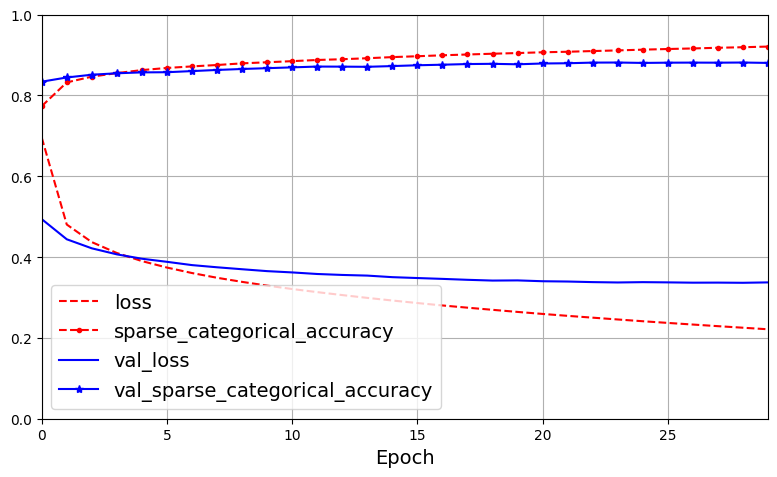

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code
save_fig("keras_learning_curves_plot")  # extra code
plt.show()

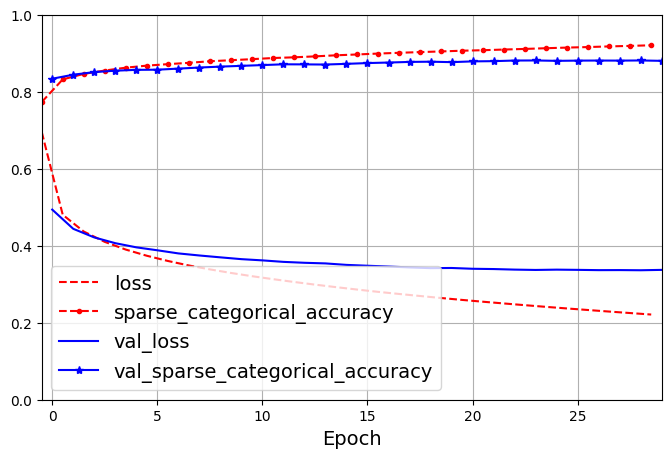

In [56]:
# extra code – shows how to shift the training curve by -1/2 epoch
plt.figure(figsize=(8, 5))
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    plt.plot(epochs, history.history[key], style, label=key)
plt.xlabel("Epoch")
plt.axis([-0.5, 29, 0., 1])
plt.legend(loc="lower left")
plt.grid()
plt.show()

In [57]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3599 - sparse_categorical_accuracy: 0.8766


[0.35986849665641785, 0.8766000270843506]

### Using the model to make predictions

- **Making Predictions**

  `y_proba = model.predict(X_new)`

- Output:
  - Returns **probabilities for each class**
  - Shape:

  ( ({num samples}, {num classes}) )

---

- **Example Output**
  - Each row = one instance
  - Each column = probability of a class

- Example (first sample):
  - Class 9 (ankle boot) → 0.97
  - Class 7 (sneaker) → 0.02
  - Class 5 (sandal) → 0.01

- Interpretation:
  - Model is **very confident** about class 9

---

- **Getting Final Predictions**

  `y_pred = y_proba.argmax(axis=-1)`

- Formula:

  $$( y_{pred} = \arg\max_i (p_i) )$$

- Meaning:
  - Select class with **highest probability**

---

- **Mapping to Class Names**

  `class_names[y_pred]`

- Example:
  - 9 → Ankle boot
  - 2 → Pullover
  - 1 → Trouser

---

- **Comparison with True Labels**

  `y_test[:3]`

- If predicted = actual:
  - Model classified correctly ✅

---

- **Key Insight**
  - predict() → probabilities
  - argmax() → final class

---

- **Relation to Scikit-Learn**
  - `predict()` (Keras) ≈ `predict_proba()` (Sklearn)
  - Need extra step (`argmax`) to get class labels

---

- **Summary Flow**
  - Input → Model → Probabilities → Argmax → Final Prediction

In [58]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.23, 0.  , 0.01, 0.  , 0.77],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [59]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])

In [60]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [61]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

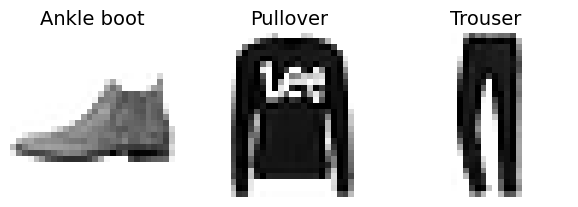

In [62]:
# extra code – this cell generates and saves Figure 10–12
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('fashion_mnist_images_plot', tight_layout=False)
plt.show()

## Building a Regression MLP Using the Sequential API

- **MLP for Regression (Keras)**

- Key differences from classification:
  - Output layer → **1 neuron** (predict single value)
  - Output activation → **None (linear output)**
  - Loss → **Mean Squared Error (MSE)**
  - Metric → **RMSE**
  - Optimizer → **Adam**

---

- **Model Architecture**

  - Input → Normalization layer  
  - Hidden layers:
    - 3 layers × 50 neurons
    - Activation: ReLU
  - Output layer:
    - 1 neuron (no activation)

---

- **Normalization Layer**
  - Standardizes input features:

  $$( X_{norm} = \frac{X - \mu}{\sigma} )$$

  - Must call:

  `norm_layer.adapt(X_train)`

  - Learns:
    - Mean $( \mu )$
    - Standard deviation $( \sigma )$

  - These are **non-trainable parameters**

---

- **Compilation**

  `model.compile(loss="mse", optimizer=Adam, metrics=["RMSE"])`

- **Loss Function**

  $$( {MSE} = \frac{1}{n} \sum (y - \hat{y})^2 )$$

- **Metric**

  $$( {RMSE} = \sqrt{{MSE}} )$$

---

- **Training**

  `model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))`

---

- **Evaluation**

  `model.evaluate(X_test, y_test)`

  - Returns:
    - Test MSE
    - Test RMSE

---

- **Prediction**

  `y_pred = model.predict(X_new)`

---

- **Key Insight**
  - No Flatten needed (data is already tabular)
  - Normalization is essential for gradient descent

---

- **Summary**
  - Regression MLP = same structure as classification  
  - Only changes:
    - Output layer
    - Loss
    - Metric

---

In [63]:
# extra code – load and split the California housing dataset, like earlier
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [64]:
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test, rmse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20


C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - RootMeanSquaredError: 0.8985 - loss: 0.8074 - val_RootMeanSquaredError: 0.8456 - val_loss: 0.7151
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6207 - loss: 0.3852 - val_RootMeanSquaredError: 1.4033 - val_loss: 1.9693
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.5906 - loss: 0.3488 - val_RootMeanSquaredError: 1.5012 - val_loss: 2.2535
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5915 - loss: 0.3498 - val_RootMeanSquaredError: 1.1769 - val_loss: 1.3851
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 0.5743 - loss: 0.3299 - val_RootMeanSquaredError: 1.1893 - val_loss: 1.4145
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5702 - loss: 0.3251 - val_RootMeanSquaredError: 0.8657 - val_loss: 0.7494
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.5569 - loss: 0.3102 -

In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ normalization (Normalization)        │ (None, 8)                   │              17 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 50)                  │             450 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,822 (65.72 KB)

 Trainable params: 5,601 (21.88 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 11,204 (43.77 KB)

>The Normalization layer learns the feature means and standard deviations in the training
data when you call the adapt() method. Yet when you display the model’s summary, these
statistics are listed as non-trainable. This is because these parameters are not affected by
gradient descent.

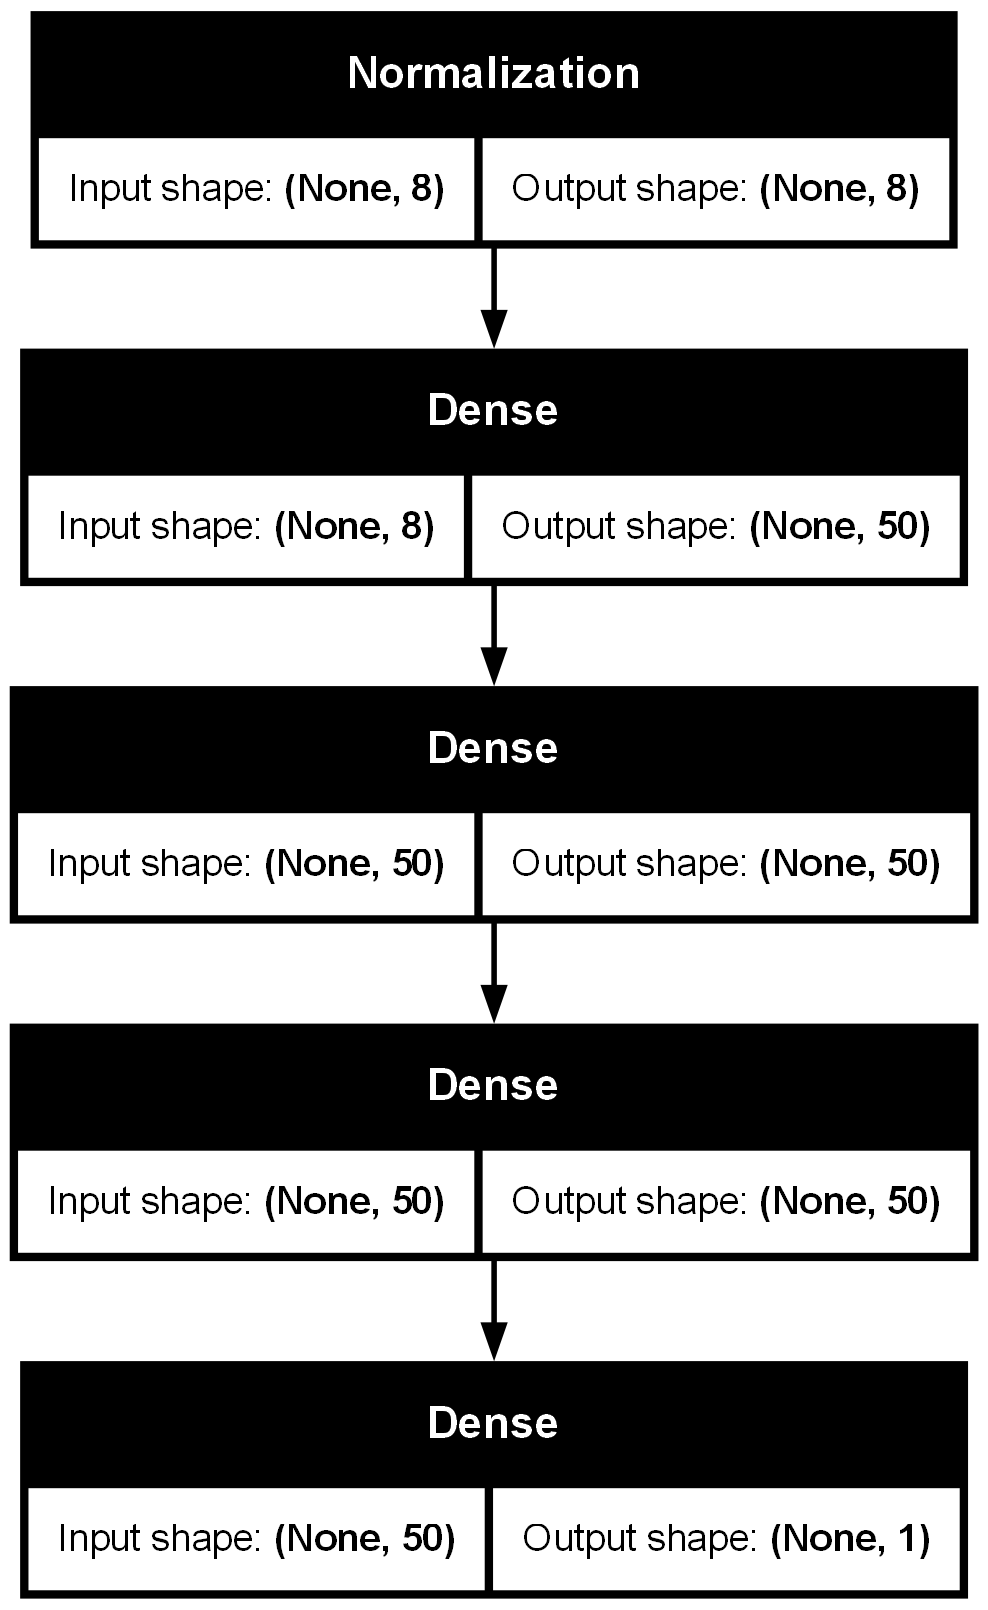

In [66]:
# extra code – another way to display the model's architecture
tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [67]:
rmse_test

0.5393558740615845

In [68]:
y_pred

array([[0.42244607],
       [1.1792253 ],
       [5.3480854 ]], dtype=float32)

## Building Complex Models Using the Functional API

- **Wide & Deep Neural Network**
  - Combines:
    - **Deep path** → learns complex patterns
    - **Wide (shortcut) path** → learns simple patterns directly

- Key idea:
  - Some inputs are **directly connected to output layer**
  - Prevents simple patterns from being distorted by deep layers

---

- **Architecture**
  - Input → Normalization
  - Deep path:
    - Dense → Dense
  - Wide path:
    - Input directly connected
  - Merge:
    - Concatenate (input + deep output)
  - Output:
    - Dense(1)

---

- **Functional API**
  - Layers are used like functions:

  $$( {output} = {layer}({input}) )$$

- Allows:
  - Multiple inputs
  - Multiple outputs
  - Complex architectures (not just sequential)

---

- **Symbolic Tensors**
  - Input and outputs are **not actual data**
  - They define **computation graph structure**

---

- **Concatenation**

  $$( {concat} = [{input}, {deep output}] )$$

  - Combines:
    - Raw features
    - Learned features

---

- **Model Creation**

  `model = tf.keras.Model(inputs=[input_], outputs=[output])`

---

- **Why Wide & Deep?**
  - Deep path → captures complex relationships
  - Wide path → preserves simple linear relationships
  - Together → better generalization

---

- **Workflow (same as before)**
  - compile()
  - adapt() (for normalization)
  - fit()
  - evaluate()
  - predict()

---

- **Key Insight**
  - Sequential API → simple stack  
  - Functional API → flexible, real-world architectures

In [69]:
# extra code – reset the name counters and make the code reproducible
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [70]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input_], outputs=[output])

In [71]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 8)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 8)                 │              17 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 30)                │             270 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 30)                │             930 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 38)                │               0 │ normalization[0][0],       │
│                               │                           │                 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1)                 │              39 │ concatenate[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,256 (4.91 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 17 (72.00 B)

In [72]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
normalization_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - RootMeanSquaredError: 0.9608 - loss: 0.9231 - val_RootMeanSquaredError: 1.0129 - val_loss: 1.0259
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6835 - loss: 0.4671 - val_RootMeanSquaredError: 1.3663 - val_loss: 1.8668
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.6360 - loss: 0.4046 - val_RootMeanSquaredError: 1.4500 - val_loss: 2.1026
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.6194 - loss: 0.3837 - val_RootMeanSquaredError: 1.0359 - val_loss: 1.0731
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.6040 - loss: 0.3648 - val_RootMeanSquaredError: 1.1356 - val_loss: 1.2895
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5975 - loss: 0.3570 - val_RootMeanSquaredError: 0.9583 - val_loss: 0.9183
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5891 - los

In [73]:
tf.random.set_seed(42)  # extra code

- **Multiple Input Neural Network (Wide & Deep Extension)**
  - Allows sending **different subsets of features** through different paths.
  - Useful when:
    - Some features are simple → wide path
    - Some features are complex → deep path
    - Some features may overlap

---

- **Input Splitting**
  - Wide input:

    $( X_{wide} = X[:, :5] )$

  - Deep input:

    $( X_{deep} = X[:, 2:] )$

- Overlap exists (features 2–4 appear in both paths).

---

- **Model Architecture**

  - Inputs:
    - $( input_{wide} \in \mathbb{R}^5 )$
    - $( input_{deep} \in \mathbb{R}^6 )$

  - Normalization:
    - $( norm_{wide} = {Normalization}(input_{wide}) )$
    - $( norm_{deep} = {Normalization}(input_{deep}) )$

  - Deep path:
    - $( hidden_1 = {ReLU}(norm_{deep}W_1 + b_1) )$
    - $( hidden_2 = {ReLU}(hidden_1W_2 + b_2) )$

  - Concatenation:
    
    $( concat = [norm_{wide}, hidden_2] )$

  - Output:
    
    $( y = concat \cdot W + b )$

---

- **Functional API 특징**
  - Layers are used like functions:

    $( output = layer(input) )$

  - Enables:
    - Multiple inputs
    - Complex architectures
    - Non-sequential flow

---

- **Model Definition**

  `model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])`

---

- **Training with Multiple Inputs**

  `model.fit((X_train_wide, X_train_deep), y_train)`

- Validation:

  `validation_data=((X_valid_wide, X_valid_deep), y_valid)`

- Evaluation:

  `model.evaluate((X_test_wide, X_test_deep), y_test)`

- Prediction:

  `model.predict((X_new_wide, X_new_deep))`

---

- **Alternative Input Format (Recommended)**

  - Use dictionary:

    `{ "input_wide": X_train_wide, "input_deep": X_train_deep }`

  - Helps avoid input order mistakes.

---

- **Why use this architecture**
  - Wide path → captures simple relationships
  - Deep path → captures complex patterns
  - Combination → better performance and generalization

---

- **Multiple Outputs (Extension)**
  - One model can produce multiple outputs:
    - Regression + Classification together
    - Multitask learning

- Benefits:
  - Shared feature learning
  - Better performance across tasks
  - Acts as regularization (reduces overfitting)

In [74]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [75]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 6)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_2               │ (None, 6)                 │              13 │ input_layer_2[0][0]        │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 30)                │             210 │ normalization_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_1               │ (None, 5)                 │              11 │ input_layer_1[0][0]        │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 30)                │             930 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 35)                │               0 │ normalization_1[0][0],     │
│                               │                           │                 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 1)                 │              36 │ concatenate_1[0][0]        │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,200 (4.70 KB)

 Trainable params: 1,176 (4.59 KB)

 Non-trainable params: 24 (104.00 B)

In [76]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), y_valid))
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)
y_pred = model.predict((X_new_wide, X_new_deep))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - RootMeanSquaredError: 1.1428 - loss: 1.3061 - val_RootMeanSquaredError: 0.7765 - val_loss: 0.6030
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.6965 - loss: 0.4850 - val_RootMeanSquaredError: 0.6619 - val_loss: 0.4380
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.6481 - loss: 0.4201 - val_RootMeanSquaredError: 0.7806 - val_loss: 0.6094
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.6243 - loss: 0.3897 - val_RootMeanSquaredError: 0.8267 - val_loss: 0.6835
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6170 - loss: 0.3807 - val_RootMeanSquaredError: 1.1308 - val_loss: 1.2788
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6107 - loss: 0.3730 - val_RootMeanSquaredError: 1.3029 - val_loss: 1.6975
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.6094 - los

- **Multiple Outputs in Neural Networks**
  - A model can have **more than one output**.
  - Example:
    - Main output → final prediction
    - Auxiliary output → helps training (regularization)

---

- **Architecture**

  - Main output:

    $( y_{main} = {Dense}(concat) )$

  - Auxiliary output:

    $( y_{aux} = {Dense}(hidden_2) )$

- Model:

  `model = Model(inputs=[input_wide, input_deep], outputs=[output, aux_output])`

---

- **Loss Functions**
  - Each output needs its own loss.

  `loss = ("mse", "mse")`

- Total loss:

  $( J = w_1 J_{main} + w_2 J_{aux} )$

---

- **Loss Weights**

  `loss_weights = (0.9, 0.1)`

- Meaning:
  - Main output → 90% importance
  - Auxiliary output → 10% importance

---

- **Compilation**

  `model.compile(loss=("mse","mse"), loss_weights=(0.9,0.1), optimizer=Adam, metrics=["RMSE"])`

---

- **Training**

  - Provide labels for both outputs:

  `model.fit((X_wide, X_deep), (y, y))`

- Validation:

  `validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))`

---

- **Evaluation**

  `model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))`

- Returns:
  - Total loss
  - Individual losses
  - Metrics for each output

---

- **Prediction**

  `y_main, y_aux = model.predict((X_new_wide, X_new_deep))`

- Output:
  - Tuple of predictions

---

- **Dictionary Conversion**

  `dict(zip(model.output_names, y_pred_tuple))`

---

- **Why use auxiliary output**
  - Forces hidden layers to learn useful features
  - Acts as **regularization**
  - Helps reduce overfitting

---

- **Key Insight**
  - Functional API enables:
    - Multiple inputs
    - Multiple outputs
    - Complex architectures

In [77]:
# Adding an auxiliary output for regularization:

In [78]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [79]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output = tf.keras.layers.Dense(1)(hidden2)
model = tf.keras.Model(inputs=[input_wide, input_deep],
                       outputs=[output, aux_output])

In [80]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 6)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_1               │ (None, 6)                 │              13 │ input_layer_1[0][0]        │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer (InputLayer)      │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 30)                │             210 │ normalization_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 5)                 │              11 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 30)                │             930 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 35)                │               0 │ normalization[0][0],       │
│                               │                           │                 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1)                 │              36 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              31 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,231 (4.82 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

In [81]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=("mse", "mse"), loss_weights=(0.9, 0.1), optimizer=optimizer,
              metrics=["RootMeanSquaredError", "RootMeanSquaredError"])

In [82]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - dense_2_RootMeanSquaredError: 1.1706 - dense_2_loss: 1.3699 - dense_3_RootMeanSquaredError: 1.4506 - dense_3_loss: 2.1036 - loss: 1.4437 - val_dense_2_RootMeanSquaredError: 1.5308 - val_dense_2_loss: 2.3423 - val_dense_3_RootMeanSquaredError: 3.3942 - val_dense_3_loss: 11.5148 - val_loss: 3.2611
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - dense_2_RootMeanSquaredError: 0.7185 - dense_2_loss: 0.5163 - dense_3_RootMeanSquaredError: 0.9277 - dense_3_loss: 0.8605 - loss: 0.5507 - val_dense_2_RootMeanSquaredError: 0.9134 - val_dense_2_loss: 0.8339 - val_dense_3_RootMeanSquaredError: 2.3523 - val_dense_3_loss: 5.5305 - val_loss: 1.3041
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - dense_2_RootMeanSquaredError: 0.6606 - dense_2_loss: 0.4364 - dense_3_RootMeanSquaredError: 0.8098 - dense_3_loss: 0.6557 - loss: 0.4583 - val_dense_2_RootMeanSquaredError: 0.6865 - val_dense_2_loss: 0.4711 - val_dense_3_RootMeanSquaredError: 1.

In [83]:
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss = eval_results[:3]

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_2_RootMeanSquaredError: 0.5867 - dense_2_loss: 0.3439 - dense_3_RootMeanSquaredError: 0.6439 - dense_3_loss: 0.4147 - loss: 0.3513


In [84]:
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


In [85]:
y_pred_tuple = model.predict((X_new_wide, X_new_deep))
y_pred = dict(zip(model.output_names, y_pred_tuple))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


In [86]:
y_pred

{'dense_2': array([[0.49880844],
        [1.170599  ],
        [3.460905  ]], dtype=float32),
 'dense_3': array([[0.49163437],
        [1.0058056 ],
        [3.1605582 ]], dtype=float32)}

In [87]:
y_pred_tuple

[array([[0.49880844],
        [1.170599  ],
        [3.460905  ]], dtype=float32),
 array([[0.49163437],
        [1.0058056 ],
        [3.1605582 ]], dtype=float32)]

## Using the Subclassing API to Build Dynamic Models

- **Declarative APIs (Sequential & Functional)**
  - Define:
    - Layers
    - Connections
  - Before training begins

- Advantages:
  - Model can be:
    - Saved
    - Cloned
    - Shared
  - Structure is visible and analyzable
  - Automatic:
    - Shape inference
    - Type checking
  - Easier debugging
  - Static computation graph

- Limitation:
  - Cannot handle:
    - Loops
    - Conditional logic
    - Dynamic behavior

---

- **Subclassing API**
  - Used for:
    - Dynamic models
    - Custom architectures
    - Research experiments

- Approach:
  - Inherit from `tf.keras.Model`
  - Define layers in `__init__()`
  - Define forward pass in `call()`

---

- **Structure**

  - Constructor:

    - Define layers:
      - Normalization layers
      - Dense layers
      - Output layers

  - Forward pass:

    - Input split:
      
      $( input = (input_{wide}, input_{deep}) )$

    - Normalize inputs
    - Pass through hidden layers
    - Concatenate:

      $( concat = [norm_{wide}, hidden_2] )$

    - Outputs:

      $( y_{main} = f(concat) )$

      $( y_{aux} = f(hidden_2) )$

---

- **Model Usage**
  - Same as other APIs:
    - compile()
    - adapt()
    - fit()
    - evaluate()
    - predict()

---

- **Key Difference**
  - Functional API → static graph
  - Subclassing API → dynamic execution

---

- **Advantages of Subclassing**
  - Full flexibility:
    - Loops
    - if/else
    - custom logic
    - low-level TensorFlow ops

---

- **Disadvantages**
  - Model structure not easily visible
  - Cannot:
    - Clone model easily
    - Fully inspect connections
  - Harder debugging
  - No early shape/type checking

---

- **Recommendation**
  - Use:
    - Sequential / Functional → most cases
  - Use Subclassing:
    - When flexibility is required

---

- **Extra Insight**
  - Keras models behave like layers:
    - Can be combined to build larger architectures

In [88]:
class WideAndDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # needed to support naming the model
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)
        
    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

tf.random.set_seed(42)  # extra code – just for reproducibility
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")

In [89]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=optimizer, metrics=["RootMeanSquaredError", "RootMeanSquaredError"])
model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)))
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - RootMeanSquaredError: 1.1564 - RootMeanSquaredError_1: 1.6024 - loss: 1.4602 - mse_loss: 2.5669 - val_RootMeanSquaredError: 1.8560 - val_RootMeanSquaredError_1: 2.3067 - val_loss: 3.6324 - val_mse_loss: 5.3184
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.6975 - RootMeanSquaredError_1: 0.9182 - loss: 0.5222 - mse_loss: 0.8431 - val_RootMeanSquaredError: 0.9510 - val_RootMeanSquaredError_1: 1.2900 - val_loss: 0.9804 - val_mse_loss: 1.6636
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6474 - RootMeanSquaredError_1: 0.7925 - loss: 0.4401 - mse_loss: 0.6281 - val_RootMeanSquaredError: 0.6674 - val_RootMeanSquaredError_1: 0.8847 - val_loss: 0.4791 - val_mse_loss: 0.7825
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.6327 - RootMeanSquaredError_1: 0.7516 - loss: 0.4167 - mse_loss: 0.5649 - val_RootMeanSquaredError: 0.6112 - val_RootMeanSquaredEr

## Saving and Restoring a Model

- **Saving a Keras Model**

  `model.save("my_keras_model", save_format="tf")`

- Default format:
  - **SavedModel (TensorFlow format)**

---

- **SavedModel Structure**
  - `saved_model.pb` → model architecture + computation graph
  - `keras_metadata.pb` → Keras-specific info
  - `variables/` → weights, biases, optimizer state
  - `assets/` → optional files (e.g., class names)

---

- **Key Advantage**
  - No need for source code to use model
  - Can directly deploy in production

---

- **Includes**
  - Model architecture
  - Weights & biases
  - Normalization stats
  - Optimizer state

- Allows:
  - **Continue training after loading**

---

- **Alternative Format**

  - HDF5 format:

  `model.save("model.h5")`

  - Stored in single file
  - Less preferred for TensorFlow deployment

---

- **Loading Model**

  `model = tf.keras.models.load_model("my_keras_model")`

- After loading:
  - Can evaluate or predict directly

---

- **Saving Only Weights**

  `model.save_weights("my_weights")`

- Loads with:

  `model.load_weights("my_weights")`

---

- **Weight Files**
  - `.data` files → parameter values
  - `.index` file → structure reference

---

- **Why save only weights**
  - Faster
  - Less storage
  - Useful for checkpoints

---

- **Checkpointing**
  - Important for long training:
    - Prevent loss if crash occurs

- Done using:
  - **Callbacks (during training)**

---

- **Key Insight**
  - Full model save → deployment
  - Weights save → training checkpoints

---

Warning: Keras's model.save() method no longer supports TensorFlow's SavedModel format. However, you can still export models to the SavedModel format using model.export() like this:

In [90]:
# extra code – delete the directory, in case it already exists

# import shutil

# shutil.rmtree("my_keras_model", ignore_errors=True)

In [91]:
model.export("my_keras_model")

INFO:tensorflow:Assets written to: my_keras_model\assets


INFO:tensorflow:Assets written to: my_keras_model\assets


Saved artifact at 'my_keras_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Tuple[TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)]
Output Type:
  Tuple[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  1988206126928: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  1988206121168: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  1988204523216: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  1988206128080: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  1988204514768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1988204516112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1988204522448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1988204516304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1988204519184: TensorSpec(shape=(), dtype=tf.resou

In [92]:
# extra code – show the contents of the my_keras_model/ directory
for path in sorted(Path("my_keras_model").glob("**/*")):
    print(path)

my_keras_model\assets
my_keras_model\fingerprint.pb
my_keras_model\saved_model.pb
my_keras_model\variables
my_keras_model\variables\variables.data-00000-of-00001
my_keras_model\variables\variables.index


**Warning**: In Keras 3, it is no longer possible to load a TensorFlow `SavedModel` as a Keras model. However, you can load a `SavedModel` as a `tf.keras.layers.TFSMLayer` layer, but be aware that this layer can only be used for inference: no training.

In [93]:
tfsm_layer = tf.keras.layers.TFSMLayer("my_keras_model")
y_pred_main, y_pred_aux = tfsm_layer((X_new_wide, X_new_deep))

In [94]:
tfsm_layer

<TFSMLayer name=tfsm_layer, built=True>

Warning: Keras now requires the saved weights to have the .weights.h5 extension. There are no longer saved using the SavedModel format.

In [95]:
model.save_weights("my_weights.weights.h5")

In [96]:
model.load_weights("my_weights.weights.h5")

To save a model using the .keras format, simply use model.save():

In [97]:
model.save("my_model.keras")

To load a .keras model, use the tf.keras.models.load_model() function. If the model uses any custom object, you must pass them to the function via the custom_objects argument:

In [98]:
loaded_model = tf.keras.models.load_model(
    "my_model.keras",
    custom_objects={"WideAndDeepModel": WideAndDeepModel}
)

## Using Callbacks

In [99]:
# extra code – delete the directory, in case it already exists

import shutil

shutil.rmtree("my_keras_model", ignore_errors=True)

In [100]:
shutil.rmtree("my_checkpoints", ignore_errors=True)  # extra code

- **Callbacks in Keras**
  - Special functions executed during training:
    - Before/after training
    - Before/after each epoch
    - Before/after each batch

- Passed using:

  `model.fit(..., callbacks=[...])`

---

- **ModelCheckpoint Callback**
  - Saves model (or weights) during training

  `ModelCheckpoint("path", save_weights_only=True)`

- Default:
  - Saves after every epoch

- Option:

  `save_best_only=True`

  - Saves only when validation performance improves

- Use:
  - Prevent losing best model
  - Helps avoid overfitting

---

- **EarlyStopping Callback**
  - Stops training when no improvement

  `EarlyStopping(patience=10, restore_best_weights=True)`

- Parameters:
  - patience → number of epochs to wait
  - restore_best_weights → reload best model

- Benefits:
  - Saves time
  - Reduces overfitting

---

- **Combining Callbacks**

  `callbacks=[checkpoint_cb, early_stopping_cb]`

- Effect:
  - Save best checkpoints
  - Stop when no progress

---

- **Epoch Strategy**
  - Set large epochs (e.g., 100+)
  - EarlyStopping will stop automatically

---

- **Custom Callbacks**
  - Create by subclassing:

  `tf.keras.callbacks.Callback`

- Example:

  $( \text{ratio} = \frac{\text{val\_loss}}{\text{loss}} )$

- Useful for:
  - Monitoring overfitting
  - Debugging

---

- **Available Callback Hooks**
  - Training:
    - on_train_begin / end
    - on_epoch_begin / end
    - on_batch_begin / end

- Evaluation:
  - on_test_begin / end
  - on_test_batch_begin / end

- Prediction:
  - on_predict_begin / end
  - on_predict_batch_begin / end

---

- **Key Insight**
  - Callbacks = control + monitoring during training
  - Essential for:
    - Checkpointing
    - Early stopping
    - Custom logic

---

In [101]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpoints.weights.h5",
                                                   save_weights_only=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb])

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.6044 - RootMeanSquaredError_1: 0.6733 - loss: 0.3742 - mse_loss: 0.4534 - val_RootMeanSquaredError: 1.1773 - val_RootMeanSquaredError_1: 0.8827 - val_loss: 1.3253 - val_mse_loss: 0.7789
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 0.6001 - RootMeanSquaredError_1: 0.6650 - loss: 0.3684 - mse_loss: 0.4422 - val_RootMeanSquaredError: 0.8650 - val_RootMeanSquaredError_1: 0.7112 - val_loss: 0.7239 - val_mse_loss: 0.5057
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5930 - RootMeanSquaredError_1: 0.6571 - loss: 0.3597 - mse_loss: 0.4319 - val_RootMeanSquaredError: 1.1397 - val_RootMeanSquaredError_1: 1.2298 - val_loss: 1.3202 - val_mse_loss: 1.5118
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.5947 - RootMeanSquaredError_1: 0.6588 - loss: 0.3617 - mse_loss: 0.4341 - val_RootMeanSquaredError: 1.3141 - val_RootMeanSquaredEr

In [102]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=100,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.5841 - RootMeanSquaredError_1: 0.6346 - loss: 0.3473 - mse_loss: 0.4028 - val_RootMeanSquaredError: 1.1406 - val_RootMeanSquaredError_1: 1.3484 - val_loss: 1.3526 - val_mse_loss: 1.8173
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.5803 - RootMeanSquaredError_1: 0.6333 - loss: 0.3432 - mse_loss: 0.4012 - val_RootMeanSquaredError: 0.7741 - val_RootMeanSquaredError_1: 0.6685 - val_loss: 0.5840 - val_mse_loss: 0.4468
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.5740 - RootMeanSquaredError_1: 0.6243 - loss: 0.3355 - mse_loss: 0.3899 - val_RootMeanSquaredError: 0.8878 - val_RootMeanSquaredError_1: 1.0892 - val_loss: 0.8280 - val_mse_loss: 1.1860
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.5719 - RootMeanSquaredError_1: 0.6239 - loss: 0.3333 - mse_loss: 0.3893 - val_RootMeanSquaredError: 0.7362 - val_RootMeanSquar

In [103]:
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [104]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[val_train_ratio_cb], verbose=0)

Epoch=0, val/train=4.66
Epoch=1, val/train=5.68
Epoch=2, val/train=7.74
Epoch=3, val/train=3.06
Epoch=4, val/train=2.88
Epoch=5, val/train=1.30
Epoch=6, val/train=2.00
Epoch=7, val/train=1.34
Epoch=8, val/train=2.69
Epoch=9, val/train=2.39


## Using TensorBoard for Visualization

In [105]:
shutil.rmtree("my_logs", ignore_errors=True)

- **TensorBoard**
  - Interactive visualization tool for deep learning.
  - Used to monitor training, analyze models, and compare experiments.

---

- **Capabilities**
  - Visualize:
    - Training & validation loss/accuracy
  - Compare multiple runs
  - View computation graph
  - Analyze training statistics
  - Visualize generated images
  - Project high-dimensional data to lower dimensions
  - Profile model performance (detect bottlenecks)

---

- **Installation**
  - Comes with TensorFlow
  - For profiling (Colab):
    - Requires additional plugin

---

- **Core Concept**
  - Model writes data to **event files (logs)**
  - Each record = **summary**
  - TensorBoard reads logs and updates visualizations (almost live)

---

- **Logging Strategy**
  - Use a **root log directory** (e.g., `my_logs`)
  - Create a **separate subdirectory for each run**
  - Prevents mixing results and enables comparison

---

- **Run Management**
  - Each run has unique folder (timestamp-based)
  - Allows:
    - Comparing hyperparameters (e.g., learning rate changes)
    - Tracking experiments cleanly

---

- **TensorBoard Callback**
  - Automatically:
    - Creates log directories
    - Writes event files
    - Logs training & validation metrics
    - Profiles model performance

---

- **Profiling**
  - Done on selected batches (not all)
  - Reason:
    - Initial batches are unstable (warm-up phase)
    - Profiling is resource-intensive

---

- **Log Structure**
  - One folder per run
  - Inside:
    - Training logs
    - Validation logs
    - Event files (metrics)
    - Profiling data

---

- **TensorBoard Server**
  - Monitors log directory
  - Updates visualizations dynamically
  - Can be launched inside Jupyter/Colab

---

- **Port**
  - Default:

  \( 6006 \)

---

- **Key Insight**
  - TensorBoard = visualization + experiment tracking + debugging
  - Essential for:
    - Understanding training behavior
    - Comparing models
    - Optimizing performance

In [106]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

In [107]:
# extra code – builds the first regression model we used earlier
tf.keras.backend.clear_session()
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [108]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid),
                    callbacks=[tensorboard_cb])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - RootMeanSquaredError: 1.4267 - loss: 2.0354 - val_RootMeanSquaredError: 0.9586 - val_loss: 0.9188
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - RootMeanSquaredError: 0.8541 - loss: 0.7295 - val_RootMeanSquaredError: 0.8262 - val_loss: 0.6825
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - RootMeanSquaredError: 0.7825 - loss: 0.6123 - val_RootMeanSquaredError: 0.7632 - val_loss: 0.5825
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.7598 - loss: 0.5773 - val_RootMeanSquaredError: 0.7477 - val_loss: 0.5591
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.7429 - loss: 0.5519 - val_RootMeanSquaredError: 0.7284 - val_loss: 0.5305
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.7285 - loss: 0.5307 - val_RootMeanSquaredError: 0.7146 - val_loss: 0.5106
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.7161 - los

In [109]:
print("my_logs")
for path in sorted(Path("my_logs").glob("**/*")):
    print("  " * (len(path.parts) - 1) + path.parts[-1])

my_logs
  run_2026_03_21_15_45_42
    train
      events.out.tfevents.1774088143.ROUSHAN_77.22416.0.v2
      plugins
        profile
          2026_03_21_10_15_45
            ROUSHAN_77.xplane.pb
    validation
      events.out.tfevents.1774088146.ROUSHAN_77.22416.1.v2


In [110]:
# loadinng in jupyter notebook
%load_ext tensorboard
%tensorboard --logdir=./my_logs

In [111]:
# # extra code

# if "google.colab" in sys.modules:
#     from google.colab import output

#     output.serve_kernel_port_as_window(6006)
# else:
#     from IPython.display import display, HTML

#     display(HTML('<a href="http://localhost:6006/">http://localhost:6006/</a>'))

In [112]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(str(test_logdir))
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        data = (np.random.randn(100) + 2) * step / 100  # gets larger
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        
        images = np.random.rand(2, 32, 32, 3) * step / 1000  # gets brighter
        tf.summary.image("my_images", images, step=step)
        
        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)
        
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

- **TensorBoard Interface**
  - SCALARS tab → view learning curves (loss, accuracy)
  - Compare multiple runs:
    - Select different logs
    - Observe effect of hyperparameters (e.g., learning rate)

- **Learning Insight**
  - Faster loss decrease → better learning rate
  - Example:
    - Higher learning rate → faster convergence (if stable)

---

- **Other Tabs in TensorBoard**
  - GRAPHS → visualize computation graph
  - PROJECTOR → visualize learned representations in 3D
  - PROFILE → analyze performance and bottlenecks

---

- **UI Controls**
  - Refresh button → update data manually
  - Settings (⚙):
    - Enable auto-refresh
    - Set refresh interval

---

- **tf.summary (Low-level API)**
  - Used for custom logging beyond training metrics
  - Can log:
    - Scalars (numbers)
    - Histograms (distributions)
    - Images
    - Audio
    - Text

- Enables:
  - Fine-grained experiment tracking
  - Custom visualizations in TensorBoard

---

- **Additional TensorBoard Tabs**
  - IMAGES → visualize images over time
  - AUDIO → listen to audio outputs
  - HISTOGRAMS / DISTRIBUTIONS → data distributions
  - TEXT → textual logs

---

- **Use Beyond Deep Learning**
  - Can visualize:
    - Any time-series data
    - Any experiment logs
  - Not limited to neural networks

---

- **Sharing Results**
  - Upload logs online
  - Get shareable link
  - Useful for collaboration and showcasing work

---

- **Key Insight**
  - TensorBoard = experiment analysis + visualization platform
  - Helps:
    - Understand training behavior
    - Compare models
    - Debug and optimize performance

---

- **Chapter Summary (What You Learned)**
  - Neural network basics and history
  - MLP for classification and regression
  - Keras APIs:
    - Sequential
    - Functional
    - Subclassing
  - Complex architectures:
    - Wide & Deep
    - Multiple inputs/outputs
  - Model saving/loading
  - Callbacks:
    - Checkpointing
    - Early stopping
  - TensorBoard for visualization

---

- **Next Step**
  - Focus on:
    - Hyperparameter tuning
    - Choosing:
      - Number of layers
      - Number of neurons
      - Learning rate
      - Other configurations

In [113]:
# extra code – lists all running TensorBoard server instances

from tensorboard import notebook

notebook.list()

Known TensorBoard instances:
  - port 6006: logdir ./my_logs (started 0:04:44 ago; pid 16924)


In [114]:
!taskkill /F /PID <pid>

The syntax of the command is incorrect.


**Note**: it used to be possible to easily share your TensorBoard logs with the world by uploading them to [deploy](https://tensorboard.dev/). Sadly, this service will shut down in December 2023, so I have removed the corresponding code examples from this notebook.

# Fine-Tuning Neural Network Hyperparameters

In [8]:
import keras_tuner as kt

In [9]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [10]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

- **Hyperparameter Challenge**
  - Neural networks are highly flexible → many hyperparameters
  - Examples:
    - Number of layers
    - Number of neurons per layer
    - Activation functions
    - Weight initialization
    - Optimizer type
    - Learning rate
    - Batch size

- **Problem**
  - Large search space → difficult to manually find best combination

---

- **Traditional Approach**
  - Use Scikit-Learn tools:
    - Grid Search
    - Random Search
  - Requires wrapping Keras model
  - Less efficient and less flexible for deep learning

---

- **Better Approach: Keras Tuner**
  - Specialized library for hyperparameter tuning in Keras
  - Features:
    - Multiple search strategies
    - High customization
    - Integration with TensorBoard

---

- **Core Idea**
  - Define a **model-building function**
  - Function:
    - Takes hyperparameters as input
    - Builds and compiles model
  - Tuner tries different combinations automatically

---

- **HyperParameters Object (hp)**
  - Used to define search space

- Types of hyperparameters:
  - Integer:

    $( n_{hidden} \in [0, 8] $)

  - Integer:

    $( n_{neurons} \in [16, 256] $)

  - Float (log scale):

    $( learning\_rate \in [10^{-4}, 10^{-2}]$)

  - Choice:

    $( optimizer \in \{SGD, Adam\} $)

---

- **Sampling Strategy**
  - Log sampling for learning rate:
    - Equal probability across scales
    - Better for exponential ranges

---

- **Dynamic Model Construction**
  - Number of layers depends on hyperparameter:

    $( \text{layers} = n_{hidden} )$

  - Each layer:
    - Uses ReLU activation

  - Output layer:
    - Softmax for classification

---

- **Optimizer Selection**
  - Based on hyperparameter choice:
    - SGD or Adam
  - Learning rate applied dynamically

---

- **Workflow**
  - Define search space (hyperparameters)
  - Build model using those values
  - Compile model
  - Return model to tuner

---

- **Key Insight**
  - Hyperparameter tuning = automated trial-and-error
  - Keras Tuner explores combinations efficiently
  - Essential for improving model performance

In [11]:
import keras_tuner as kt

def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                             sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model

- **Random Search with Keras Tuner**
  - Uses random sampling of hyperparameters to find good models.
  - Simpler and often effective compared to exhaustive search.

---

- **Tuner Setup**
  - Requires:
    - Model-building function
    - Objective metric (e.g., validation accuracy)
    - Number of trials
    - Storage directory for results

---

- **Search Process**
  - Step 1:
    - Calls model-building function once
    - Registers all hyperparameters (search space)

  - Step 2:
    - Runs multiple trials:
      - Randomly selects hyperparameters
      - Builds model
      - Trains model
      - Evaluates on validation set
      - Saves results

---

- **Trials**
  - Each trial = one complete experiment
  - Includes:
    - Specific hyperparameter combination
    - Model training + evaluation

---

- **Objective**
  - Defines what to optimize:
    
    $( \text{maximize } val\_accuracy )$

  - Best model = highest validation performance

---

- **Experiment Management**
  - Results saved in structured directories
  - Option to:
    - Overwrite previous runs
    - Continue tuning from last state

---

- **Best Model Selection**
  - Retrieve top-performing models
  - Retrieve best hyperparameters
  - Example:

    $( \text{best params} = \{n_{hidden}, n_{neurons}, learning\_rate, optimizer\} )$

---

- **Oracle Concept**
  - Controls hyperparameter selection
  - Keeps track of all trials
  - Suggests next configuration

- RandomSearch:
  - Uses random selection strategy

---

- **Trial Evaluation**
  - Each trial stores:
    - Hyperparameters used
    - Performance score (e.g., validation accuracy)

- Best trial:
  - Highest score among all trials

---

- **Metrics Access**
  - Can retrieve:
    - Validation accuracy
    - Other tracked metrics

---

- **Final Step (After Tuning)**
  - Take best model
  - Train on full dataset
  - Evaluate on test set
  - Deploy to production

---

- **Key Insight**
  - Random search = efficient exploration of hyperparameter space
  - Keras Tuner automates experimentation
  - Focus on validation performance for model selection

In [12]:
random_search_tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=5, overwrite=True,
    directory="my_fashion_mnist", project_name="my_rnd_search", seed=42)
random_search_tuner.search(X_train, y_train, epochs=10,
                           validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 01m 26s]
val_accuracy: 0.8381999731063843

Best val_accuracy So Far: 0.8551999926567078
Total elapsed time: 00h 07m 21s


In [13]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [14]:
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values  # best hyperparameter values

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

In [15]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8551999926567078


In [16]:
best_trial.metrics.get_last_value("val_accuracy")

np.float64(0.8551999926567078)

In [17]:
best_model.fit(X_train_full, y_train_full, epochs=10)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8676 - loss: 0.3594
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8723 - loss: 0.3452
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8778 - loss: 0.3321
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8821 - loss: 0.3212
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8854 - loss: 0.3108
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8895 - loss: 0.3025
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8925 - loss: 0.2946
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8949 - loss: 0.2877
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8981 - loss: 0.2808
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8997 - loss: 0.2744
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8628 - loss: 0.4014


- **Tuning Beyond Model Architecture**
  - Can also tune:
    - Data preprocessing (e.g., normalization)
    - Training parameters (e.g., batch size)
  - Requires more control than basic build function

---

- **HyperModel (Advanced Approach)**
  - Subclass a HyperModel
  - Define two methods:
    - build() → create model
    - fit() → control training process

- **Purpose**
  - Allows tuning:
    - Preprocessing steps
    - Training behavior
    - Input transformations

---

- **Custom Fit Logic**
  - Can conditionally modify data:
    - Example: apply normalization only if selected
  - Can adjust:
    - Batch size
    - Data pipeline
    - Training strategy

---

- **Hyperband Tuner**
  - Efficient hyperparameter search strategy
  - Works by:
    - Training many models briefly
    - Eliminating poor performers
    - Allocating more resources to promising models

- **Core Idea**
  - Successive halving:

    $( \text{keep top } \frac{1}{factor} \text{ models} )$

- Benefits:
  - Faster than random search
  - Better resource allocation

---

- **Hyperband Parameters**
  - max_epochs → max training for best model
  - factor → reduction rate (e.g., 3)
  - iterations → repeat process multiple times

---

- **Integration with TensorBoard**
  - Logs all trials
  - Visualizes:
    - Performance
    - Hyperparameter impact

- **HPARAMS Tab**
  - Shows:
    - Hyperparameter combinations
    - Corresponding performance

---

- **Visualization Insights**
  - Parallel coordinates → relationships between parameters
  - Scatter plots → interaction effects
  - Helps identify:
    - Best ranges
    - Important parameters

---

- **Bayesian Optimization**
  - Smarter search strategy
  - Learns from previous trials
  - Focuses on promising regions

- Based on:
  - Probabilistic model (Gaussian process)

- Key parameters:
  - alpha → noise level
  - beta → exploration vs exploitation

- Advantage:
  - More efficient than random search
  - Better convergence to optimal values

---

- **Other Advanced Approaches**
  - Evolutionary algorithms:
    - Optimize hyperparameters + architectures
  - AutoML:
    - Automates full ML pipeline
  - Neuroevolution:
    - Train networks without gradient descent

---

- **Key Insight**
  - Hyperparameter tuning = optimization problem
  - Strategies:
    - Random → simple but coarse
    - Hyperband → efficient resource usage
    - Bayesian → intelligent search

---

- **Practical Advice**
  - Start with reasonable defaults
  - Narrow search space
  - Then apply tuning methods

---

- **Final Takeaway**
  - Tools help automate search
  - But intuition + constraints still important

In [18]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, X, y, **kwargs):
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            norm_layer.adapt(X)
            X = norm_layer(X)
        return model.fit(X, y, **kwargs)

In [19]:
hyperband_tuner = kt.Hyperband(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_epochs=10, factor=3, hyperband_iterations=2,
    overwrite=True, directory="my_fashion_mnist", project_name="hyperband")

In [20]:
root_logdir = Path(hyperband_tuner.project_dir) / "tensorboard"
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)
hyperband_tuner.search(X_train, y_train, epochs=10,
                       validation_data=(X_valid, y_valid),
                       callbacks=[early_stopping_cb, tensorboard_cb])

Trial 60 Complete [00h 01m 42s]
val_accuracy: 0.8393999934196472

Best val_accuracy So Far: 0.8679999709129333
Total elapsed time: 00h 51m 13s


In [21]:
bayesian_opt_tuner = kt.BayesianOptimization(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_trials=10, alpha=1e-4, beta=2.6,
    overwrite=True, directory="my_fashion_mnist", project_name="bayesian_opt")
bayesian_opt_tuner.search(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stopping_cb])

Trial 10 Complete [00h 01m 25s]
val_accuracy: 0.8398000001907349

Best val_accuracy So Far: 0.855400025844574
Total elapsed time: 00h 16m 02s


In [23]:
# %tensorboard --logdir {root_logdir}

## Number of Hidden Layers

- **Starting Point**
  - Begin with:
    - 1 hidden layer → often sufficient for many problems
  - A single hidden layer can theoretically approximate any function (with enough neurons)

---

- **Shallow vs Deep Networks**
  - Shallow network:
    - Requires many neurons for complex tasks
  - Deep network:
    - More parameter-efficient
    - Can represent complex functions using fewer neurons

---

- **Why Deep Networks Work Better**
  - Real-world data has **hierarchical structure**
  - Deep networks learn features layer by layer:

    - Lower layers → simple features (edges, lines)
    - Middle layers → intermediate features (shapes)
    - Higher layers → complex features (objects, faces)

---

- **Hierarchical Learning Insight**
  - Similar to building:
    - Leaf → branch → tree → forest
  - Reuse of learned patterns reduces complexity

---

- **Advantages of Deep Networks**
  - Faster convergence
  - Better generalization
  - Efficient feature reuse

---

- **Transfer Learning**
  - Reuse lower layers from a pretrained model
  - Only train higher layers for new task

- Benefits:
  - Less training data required
  - Faster training
  - Better performance

---

- **Practical Guidelines**
  - Start with:
    - 1–2 hidden layers
  - Increase layers:
    - For more complex problems
    - Until overfitting starts

---

- **Performance Insight**
  - Example:
    - 1 hidden layer → ~97% accuracy
    - 2 hidden layers → ~98% accuracy
  - Same number of neurons → better results with depth

---

- **Very Complex Tasks**
  - Require:
    - Dozens or hundreds of layers
    - Large datasets
  - Usually solved using:
    - Pretrained models
    - Not trained from scratch

---

- **Key Insight**
  - Depth enables:
    - Hierarchical feature learning
    - Efficient representation of complex patterns

## Number of Neurons per Hidden Layer

- **Input & Output Layers**
  - Determined by the problem:
    - Input neurons = number of features
    - Output neurons = number of predictions/classes

  - Example (MNIST):
    
    $( input = 28 \times 28 = 784 )$
    
    $( output = 10 )$

---

- **Hidden Layer Sizing (Old Approach)**
  - Pyramid structure:
    - Decreasing neurons per layer
  - Example:
    - 300 → 200 → 100

- Rationale:
  - Low-level features combine into high-level features

---

- **Modern Practice**
  - Use same number of neurons in all hidden layers
  - Reasons:
    - Performs equally well or better
    - Simpler tuning (fewer hyperparameters)

- Exception:
  - First hidden layer can sometimes be larger

---

- **Choosing Number of Neurons**
  - Increase gradually until:
    - Model starts overfitting

- Alternative strategy:
  - Start with larger model
  - Control overfitting using:
    - Early stopping
    - Regularization

---

- **“Stretch Pants” Approach**
  - Use a model slightly larger than needed
  - Let training + regularization adjust it

- Benefits:
  - Avoids underfitting
  - Reduces need for precise tuning

---

- **Bottleneck Problem**
  - Too few neurons in a layer → information loss

- Example:
  - Input: 3D data
  - Layer: 2 neurons → reduces to 2D
  - Lost information cannot be recovered later

---

- **Key Insight**
  - Avoid very small hidden layers (bottlenecks)
  - Ensure enough representational capacity

---

- **Practical Tip**
  - Increasing depth (layers) is usually more effective than:
    - Increasing width (neurons per layer)

## Learning Rate, Batch Size, and Other Hyperparameters

- **Important Hyperparameters in MLP**

---

- **Learning Rate**
  - Most important hyperparameter
  - Too small → slow training
  - Too large → divergence (loss increases)

- **Finding Optimal Learning Rate**
  - Gradually increase learning rate during training
  - Observe loss behavior:

    - Loss ↓ → good region  
    - Loss ↑ → too high  

  - Optimal learning rate ≈ slightly below divergence point

- Insight:

  $( \eta_{optimal} \approx \frac{1}{10} \times \eta_{divergence} )$

---

- **Optimizer**
  - Controls how weights are updated
  - Better optimizers → faster convergence, better results
  - Choice significantly impacts performance

---

- **Batch Size**
  - Number of samples per training step

- Large batch size:
  - Faster (efficient on GPU)
  - May cause:
    - Training instability
    - Poor generalization

- Small batch size:
  - Slower
  - Better generalization

- Trade-off:
  - Try large batch + learning rate warmup
  - If unstable → switch to smaller batch (e.g., 2–32)

---

- **Activation Function**
  - Hidden layers:
    - ReLU (default choice)
  - Output layer:
    - Depends on task:
      - Classification → softmax/sigmoid
      - Regression → linear/ReLU

---

- **Number of Iterations (Epochs)**
  - Usually not manually tuned
  - Use **early stopping** instead

---

- **Hyperparameter Dependency**
  - Hyperparameters are interdependent
  - Example:

    $( \eta \propto \text{batch size} )$

  - Changing one requires adjusting others

---

- **Practical Strategy**
  - Start with:
    - Reasonable defaults
  - Then:
    - Tune learning rate first
    - Adjust batch size and optimizer
    - Fine-tune architecture

---

- **Key Insight**
  - Learning rate = most critical factor
  - Batch size = trade-off between speed and generalization
  - Use early stopping to avoid unnecessary tuning

# Exercises(2-10)

## Draw an ANN using the original artificial neurons (like the ones in Figure 10-3) that computes A ⊕ B (where ⊕ represents the XOR operation). Hint: A ⊕ B = (A ∧ ¬ B) ∨ (¬ A ∧ B).

Here is a neural network based on the original artificial neurons that computes A ⊕ B (where ⊕ represents the exclusive OR), using the fact that A ⊕ B = (A ∧ ¬ B) ∨ (¬ A ∧ B). There are other solutions—for example, using the fact that A ⊕ B = (A ∨ B) ∧ ¬(A ∧ B), or the fact that A ⊕ B = (A ∨ B) ∧ (¬ A ∨ ¬ B), and so on.

## 3. Why is it generally preferable to use a logistic regression classifier rather than a classic perceptron (i.e., a single layer of threshold logic units trained using the perceptron training algorithm)? How can you tweak a perceptron to make it equivalent to a logistic regression classifier?

A classical Perceptron will converge only if the dataset is linearly separable, and it won't be able to estimate class probabilities. In contrast, a Logistic Regression classifier will generally converge to a reasonably good solution even if the dataset is not linearly separable, and it will output class probabilities. If you change the Perceptron's activation function to the sigmoid activation function (or the softmax activation function if there are multiple neurons), and if you train it using Gradient Descent (or some other optimization algorithm minimizing the cost function, typically cross entropy), then it becomes equivalent to a Logistic Regression classifier.

## 4. Why was the sigmoid activation function a key ingredient in training the first MLPs?


The sigmoid activation function was a key ingredient in training the first MLPs because its derivative is always nonzero, so Gradient Descent can always roll down the slope. When the activation function is a step function, Gradient Descent cannot move, as there is no slope at all.

## 5. Name three popular activation functions. Can you draw them?

Popular activation functions include the step function, the sigmoid function, the hyperbolic tangent (tanh) function, and the Rectified Linear Unit (ReLU) function. See Chapter 11 for other examples, such as ELU and variants of the ReLU function.

## 6. Suppose you have an MLP composed of one input layer with 10 passthrough neurons, followed by one hidden layer with 50 artificial neurons, and finally one output layer with 3 artificial neurons. All artificial neurons use the ReLU activation function.
1. What is the shape of the input matrix X?
2. What are the shapes of the hidden layer’s weight matrix W and
bias vector b ?
3. What are the shapes of the output layer’s weight matrix W and
bias vector b ?
4. What is the shape of the network’s output matrix Y?
5. Write the equation that computes the network’s output matrix Y as
6. function of X, W , b , W , and b .

- The shape of the input matrix X is m × 10, where m represents the training batch size
- The shape of the hidden layer's weight matrix **W**<sub>_h_</sub> is 10 × 50, and the length of its bias vector **b**<sub>_h_</sub> is 50.
- The shape of the output layer's weight matrix **W**<sub>_o_</sub> is 50 × 3, and the length of its bias vector **b**<sub>_o_</sub> is 3.
- The shape of the network's output matrix **Y** is _m_ × 3
- The shape of the network's output matrix **Y** is _m_ × 3.
- **Y** = ReLU(ReLU(**X** **W**<sub>_h_</sub> + **b**<sub>_h_</sub>) **W**<sub>_o_</sub> + **b**<sub>_o_</sub>). Recall that the ReLU function just sets every negative number in the matrix to zero. Also note that when you are adding a bias vector to a matrix, it is added to every single row in the matrix, which is called _broadcasting_.

## 7. How many neurons do you need in the output layer if you want to classify email into spam or ham? What activation function should you use in the output layer? If instead you want to tackle MNIST, how many neurons do you need in the output layer, and which activation function should you use? What about for getting your network to predict housing prices, as in Chapter 2?

To classify email into spam or ham, you just need one neuron in the output layer of a neural network—for example, indicating the probability that the email is spam. You would typically use the sigmoid activation function in the output layer when estimating a probability. If instead you want to tackle MNIST, you need 10 neurons in the output layer, and you must replace the sigmoid function with the softmax activation function, which can handle multiple classes, outputting one probability per class. If you want your neural network to predict housing prices like in Chapter 2, then you need one output neuron, using no activation function at all in the output layer. Note: when the values to predict can vary by many orders of magnitude, you may want to predict the logarithm of the target value rather than the target value directly. Simply computing the exponential of the neural network's output will give you the estimated value (since exp(log v) = v).

## 8. What is backpropagation and how does it work? What is the difference between backpropagation and reverse-mode autodiff?

Backpropagation is a technique used to train artificial neural networks. It first computes the gradients of the cost function with regard to every model parameter (all the weights and biases), then it performs a Gradient Descent step using these gradients. This backpropagation step is typically performed thousands or millions of times, using many training batches, until the model parameters converge to values that (hopefully) minimize the cost function. To compute the gradients, backpropagation uses reverse-mode autodiff (although it wasn't called that when backpropagation was invented, and it has been reinvented several times). Reverse-mode autodiff performs a forward pass through a computation graph, computing every node's value for the current training batch, and then it performs a reverse pass, computing all the gradients at once (see Appendix B for more details). So what's the difference? Well, backpropagation refers to the whole process of training an artificial neural network using multiple backpropagation steps, each of which computes gradients and uses them to perform a Gradient Descent step. In contrast, reverse-mode autodiff is just a technique to compute gradients efficiently, and it happens to be used by backpropagation.

## 9. Can you list all the hyperparameters you can tweak in a basic MLP? If the MLP overfits the training data, how could you tweak these hyperparameters to try to solve the problem?

Here is a list of all the hyperparameters you can tweak in a basic MLP: the number of hidden layers, the number of neurons in each hidden layer, and the activation function used in each hidden layer and in the output layer. In general, the ReLU activation function (or one of its variants; see Chapter 11) is a good default for the hidden layers. For the output layer, in general you will want the sigmoid activation function for binary classification, the softmax activation function for multiclass classification, or no activation function for regression. If the MLP overfits the training data, you can try reducing the number of hidden layers and reducing the number of neurons per hidden layer.

## 10. Train a deep MLP on the MNIST dataset (you can load it using tf.keras. data⁠ sets.mnist.load_data()). See if you can get over 98% accuracy by manually tuning the hyperparameters. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding  the point where the loss shoots up). Next, try tuning the hyperparameters using Keras Tuner with all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.

In [24]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [25]:
print(X_train_full.shape)
print(X_train_full.dtype)

(60000, 28, 28)
uint8


In [26]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

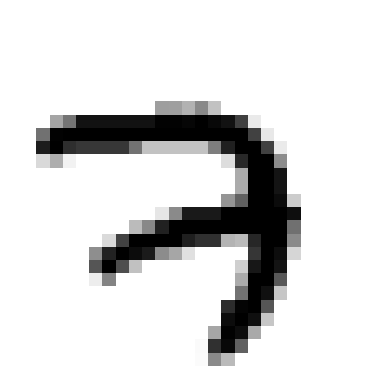

In [27]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

In [28]:
y_train

array([7, 3, 4, ..., 5, 6, 8], shape=(55000,), dtype=uint8)

In [29]:
print(X_valid.shape)
print(X_test.shape)

(5000, 28, 28)
(10000, 28, 28)


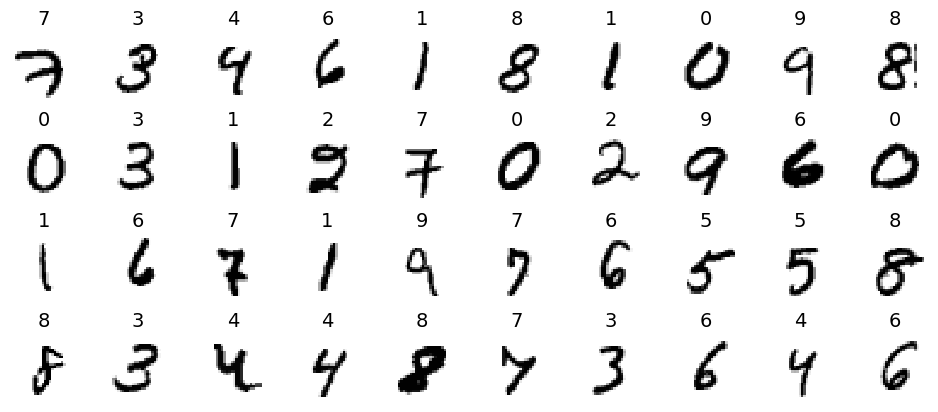

In [30]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [31]:
K = tf.keras.backend
# Let's build a simple dense network and find the optimal learning rate.
# We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:
class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])

In [33]:
import numpy as np
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [34]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.005)
# We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [36]:
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.5866 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


Text(0, 0.5, 'Loss')

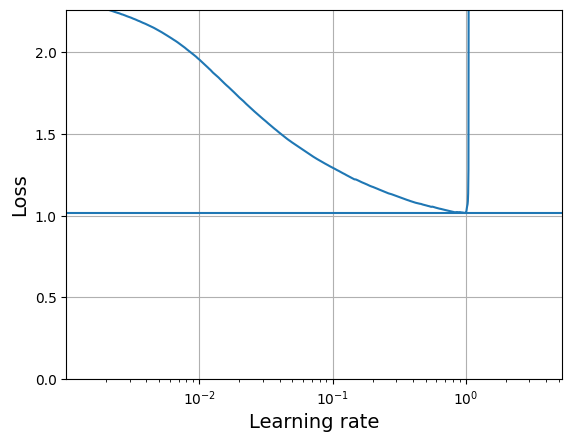

In [37]:
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")
# plot of learning rate

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [38]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [39]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [40]:
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [41]:
run_index = 1 # increment this at every run
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)
run_logdir

WindowsPath('my_mnist_logs/run_001')

In [42]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9276 - loss: 0.2326 - val_accuracy: 0.9692 - val_loss: 0.1073
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9726 - loss: 0.0909 - val_accuracy: 0.9728 - val_loss: 0.0862
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9813 - loss: 0.0600 - val_accuracy: 0.9774 - val_loss: 0.0793
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9861 - loss: 0.0443 - val_accuracy: 0.9692 - val_loss: 0.1150
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9893 - loss: 0.0326 - val_accuracy: 0.9790 - val_loss: 0.0876
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9908 - loss: 0.0273 - val_accuracy: 0.9802 - val_loss: 0.0828
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9925 - loss: 0.0232 - val_accuracy: 0.9780 - val_loss: 0.0891
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9926 -

In [43]:
model = tf.keras.models.load_model("my_mnist_model.keras") # rollback to best model
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9777 - loss: 0.0773


[0.07727275043725967, 0.9776999950408936]

In [45]:
%load_ext tensorboard
%tensorboard --logdir=./my_mnist_logs

In [46]:
# --end--